# **IMPORT THE REQUIRED LIBRARIES**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [ ]:
# to scale data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#algorithm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

#metrics for evaluation
from sklearn import metrics
from sklearn.metrics import confusion_matrix , classification_report , precision_recall_curve , f1_score, recall_score


#tree
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

#ensemble
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

import scipy.stats as stats

#for tuning
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

IMPORT THE **DATASET**

In [ ]:
df=pd.read_csv("/content/loan_dataset.csv")

In [ ]:
# making a dublicate dataset so that original one does not changes
data = df.copy()

In [ ]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [ ]:
data.shape

(5960, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [ ]:
# missing values
data.isnull().sum()

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


In [ ]:
# missing values in percentage
data.isnull().sum()/data.shape[0] * 100

,0
BAD,0.000000
LOAN,0.000000
MORTDUE,8.691275
VALUE,1.879195
REASON,4.228188
JOB,4.681208
YOJ,8.640940
DEROG,11.879195
DELINQ,9.731544
CLAGE,5.167785


CONVERTING DATA TYPES


In [ ]:
#adding target variable to this list as this is a classification problem and the target variable is categorical
cols = data.select_dtypes(['object']).columns.tolist()
cols.append('BAD')

In [ ]:
cols

['REASON', 'JOB', 'BAD']

In [ ]:
# Changing the data type of object type column to category.

for i in cols:
    data[i] = data[i].astype("category")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   BAD      5960 non-null   category
 1   LOAN     5960 non-null   int64   
 2   MORTDUE  5442 non-null   float64 
 3   VALUE    5848 non-null   float64 
 4   REASON   5708 non-null   category
 5   JOB      5681 non-null   category
 6   YOJ      5445 non-null   float64 
 7   DEROG    5252 non-null   float64 
 8   DELINQ   5380 non-null   float64 
 9   CLAGE    5652 non-null   float64 
 10  NINQ     5450 non-null   float64 
 11  CLNO     5738 non-null   float64 
 12  DEBTINC  4693 non-null   float64 
dtypes: category(3), float64(9), int64(1)
memory usage: 483.7 KB


ANALYZING SUMMARY STATISTICS OF THE DATASET

In [ ]:
# Analyzing the summary statistics for numerical variables

num_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000
DEBTINC,4693.0,33.779915,8.601746,0.524499,29.140031,34.818262,39.003141,203.312149


In [ ]:
# Checking summary for categorical data

data.describe(include=['category']).T

,count,unique,top,freq
BAD,5960,2,0,4771
REASON,5708,2,DebtCon,3928
JOB,5681,6,Other,2388


In [ ]:
# check count of unique values in categorical column

cols_cat = data.select_dtypes(['category'])

for i in cols_cat.columns:
  print('Unique values in',i,'are:')
  print(data[i].value_counts(normalize= True))
  print('*'*40)

Unique values in BAD are:
BAD
0    0.800503
1    0.199497
Name: proportion, dtype: float64
****************************************
Unique values in REASON are:
REASON
DebtCon    0.688157
HomeImp    0.311843
Name: proportion, dtype: float64
****************************************
Unique values in JOB are:
JOB
Other      0.420349
ProfExe    0.224608
Office     0.166872
Mgr        0.135011
Self       0.033973
Sales      0.019187
Name: proportion, dtype: float64
****************************************


# **EDA AND VISUALIZATION**

In [ ]:
# for doing uni-variate analysis of numerical variables we want to study thier central dendency and dispersion
# histogram and box plot
def histogram_boxplot( feature, figsize=(15, 10), kde=False, bins=None):

  f2 , (ax_box2, ax_hist2) = plt.subplots(nrows=2,
                                          sharex= True,
                                          gridspec_kw={"height_ratios": (0.25, 0.75)},
                                          figsize=figsize
                                          )

  sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='violet')

  if bins is not None:
      sns.histplot(x=feature, ax=ax_hist2, kde=kde, bins=bins, color='skyblue')
  else:
      sns.histplot(x=feature, ax=ax_hist2, kde=kde, color='skyblue')
  ax_hist2.axvline(np.mean(feature), color='green', linestyle='--')
  ax_hist2.axvline(np.median(feature), color='black', linestyle='-')


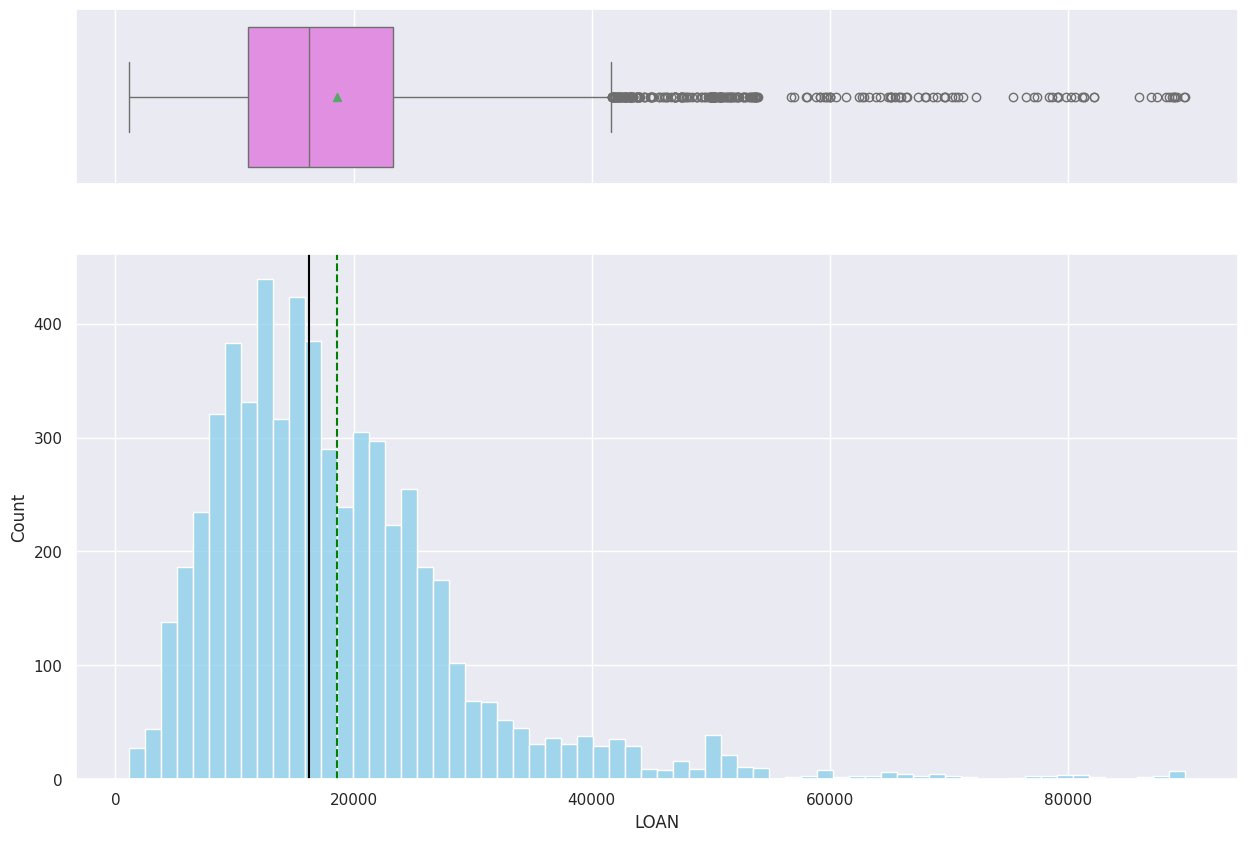

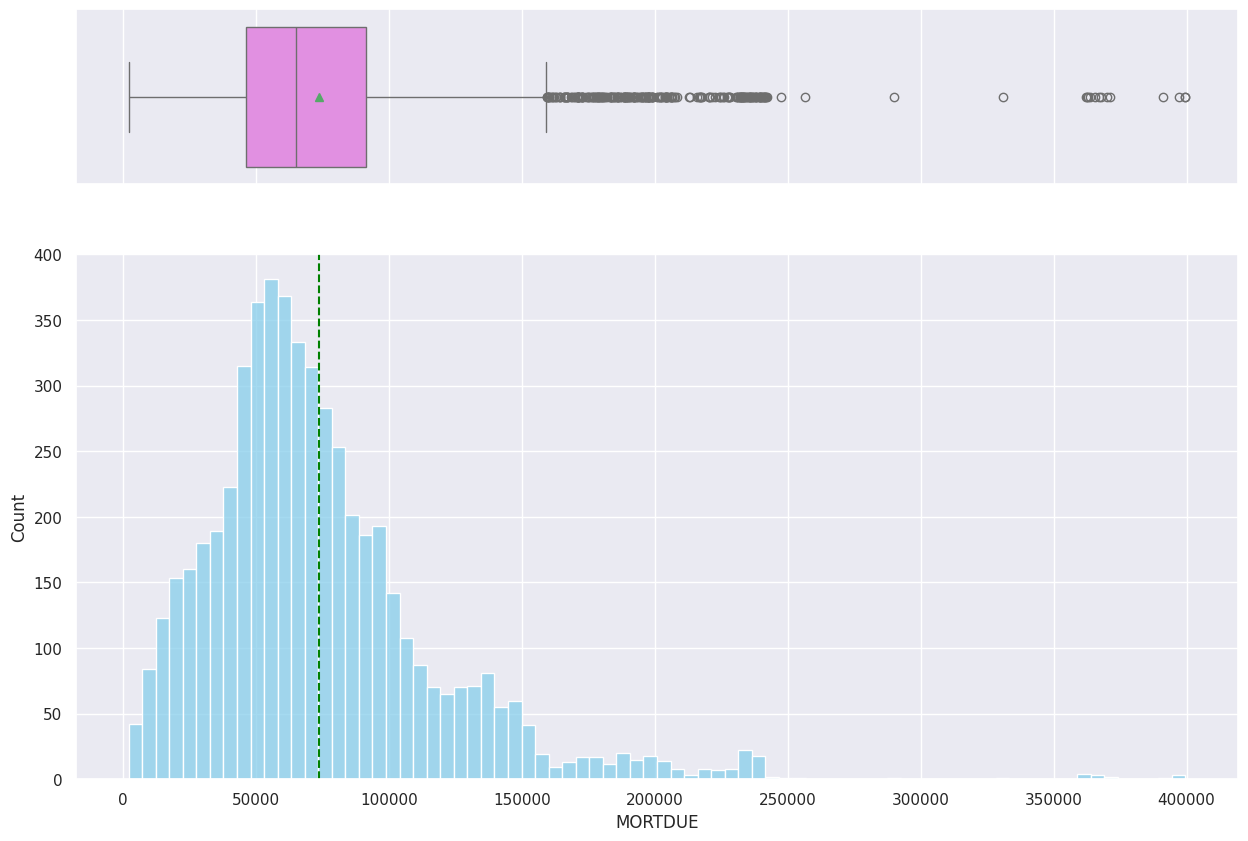

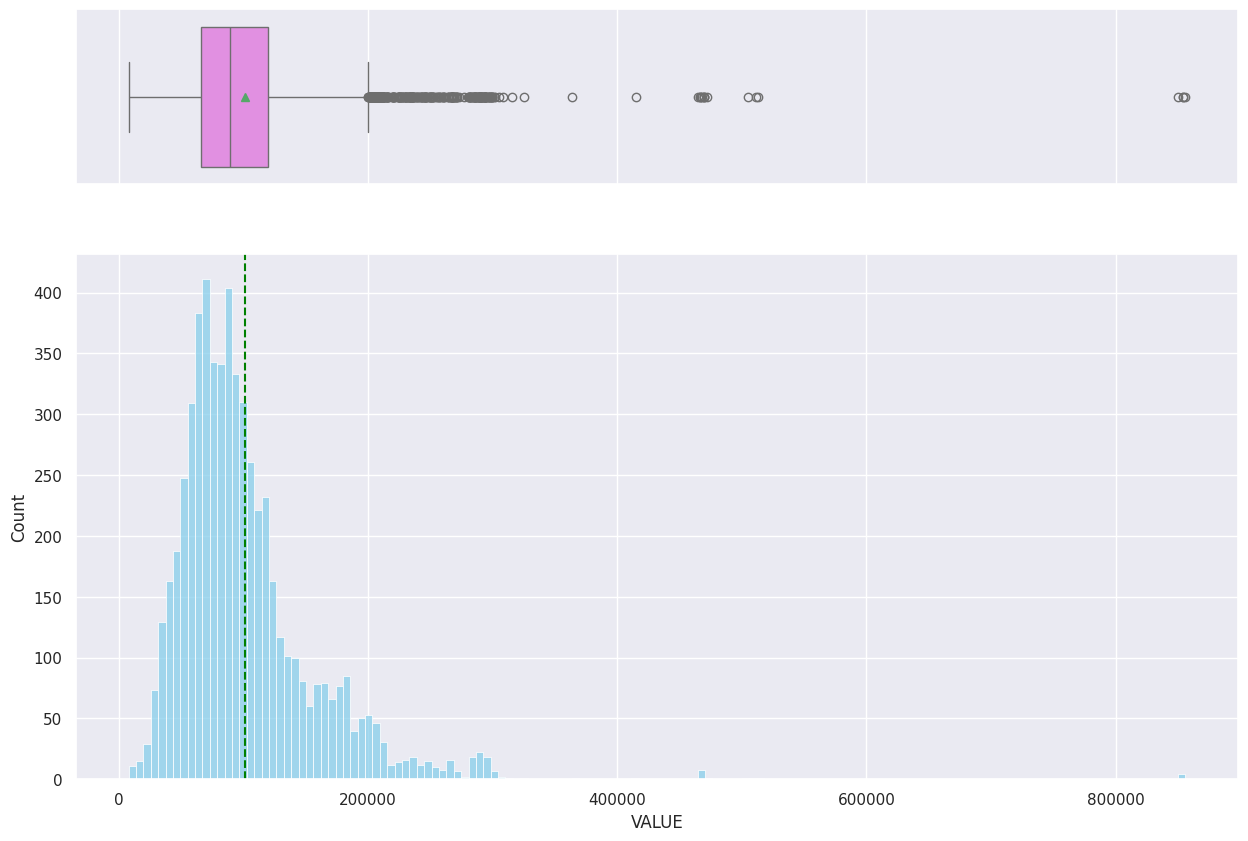

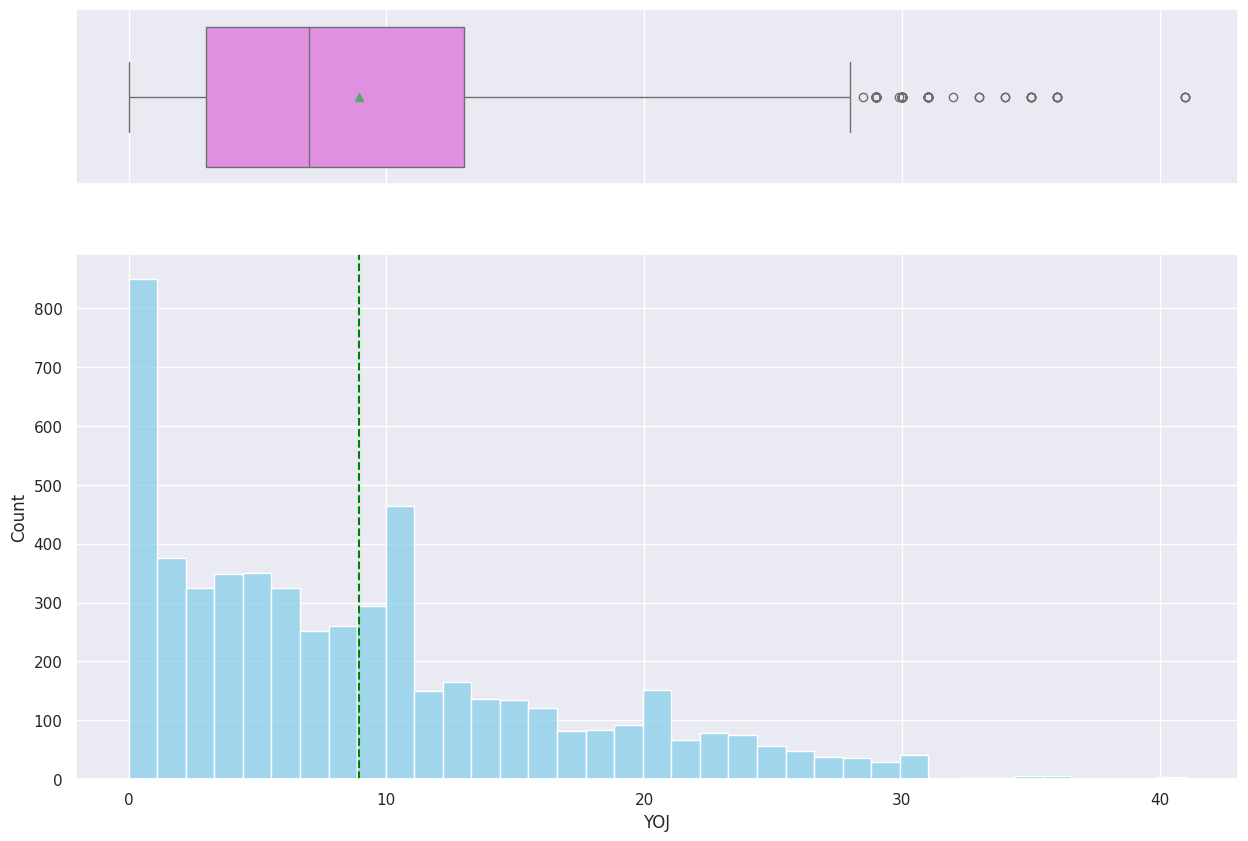

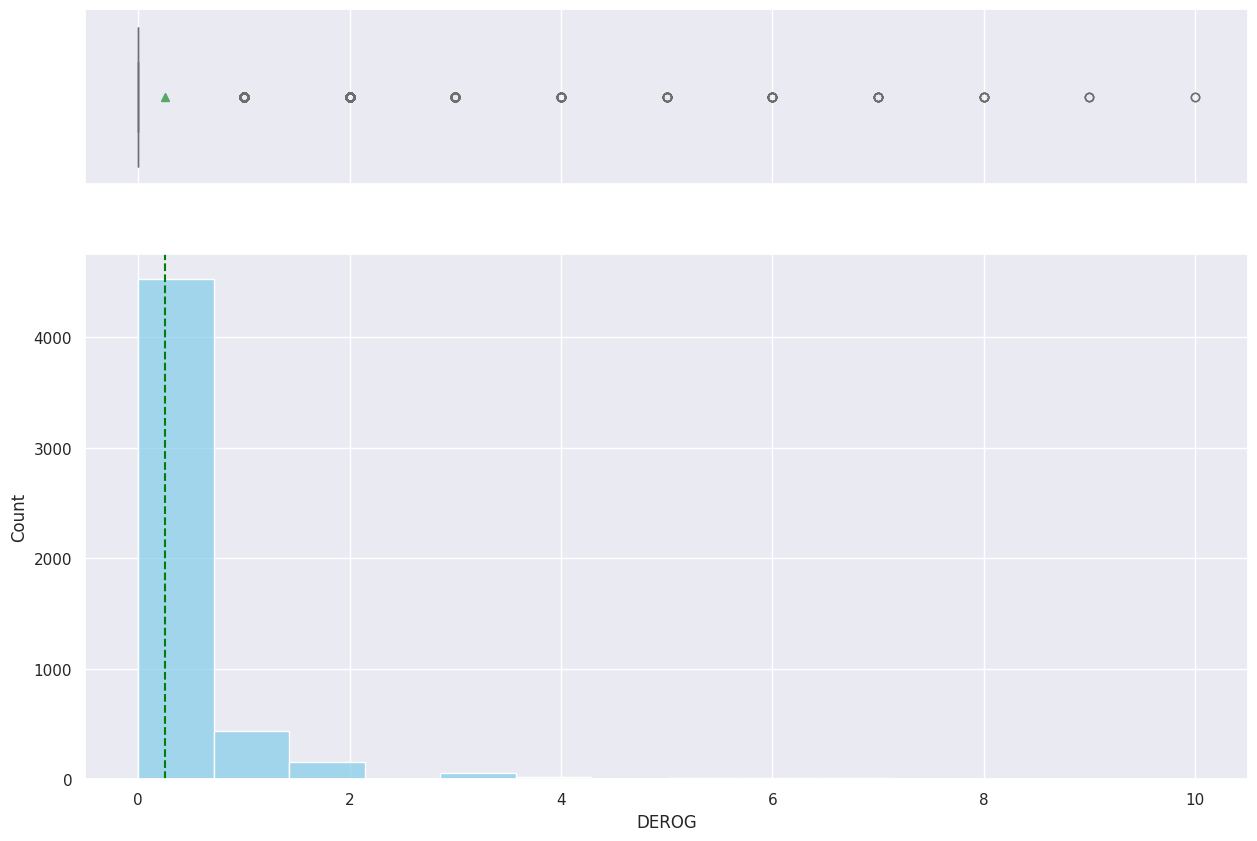

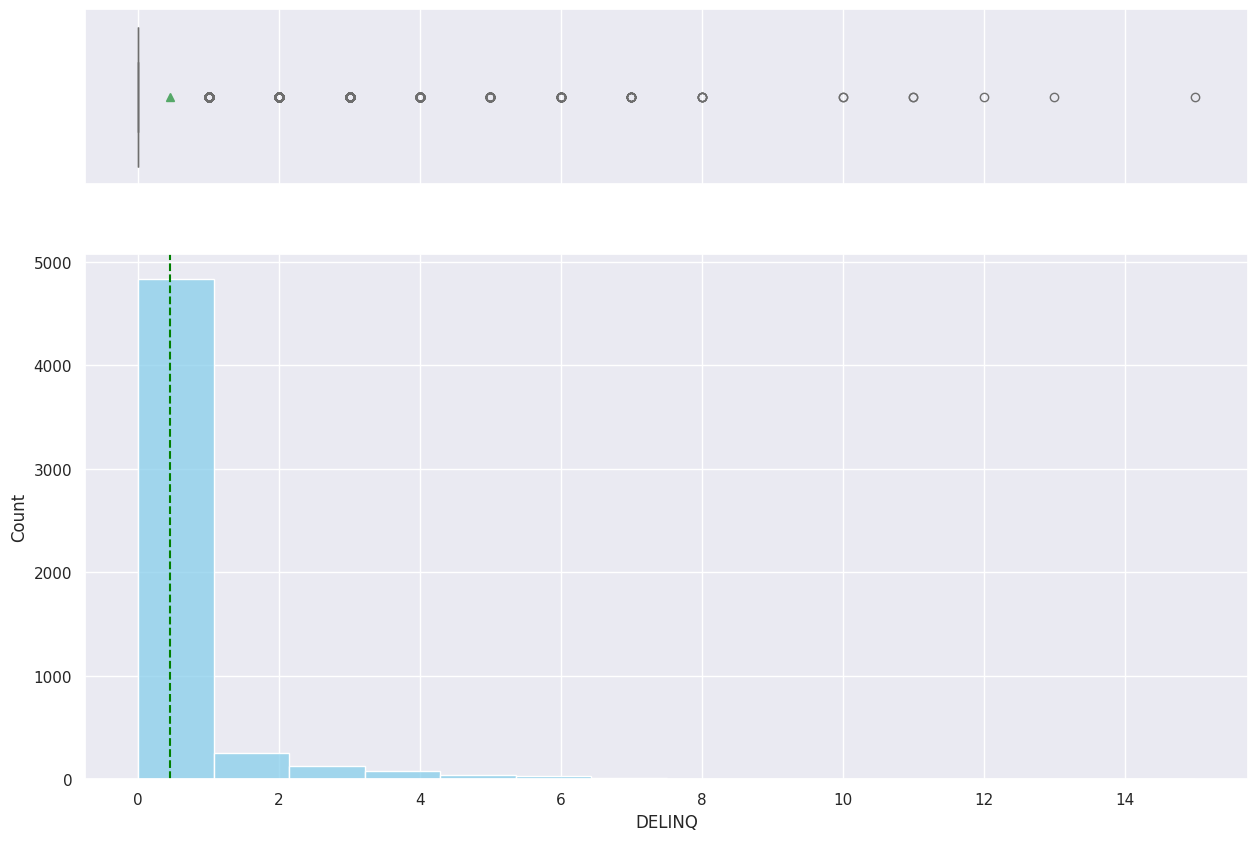

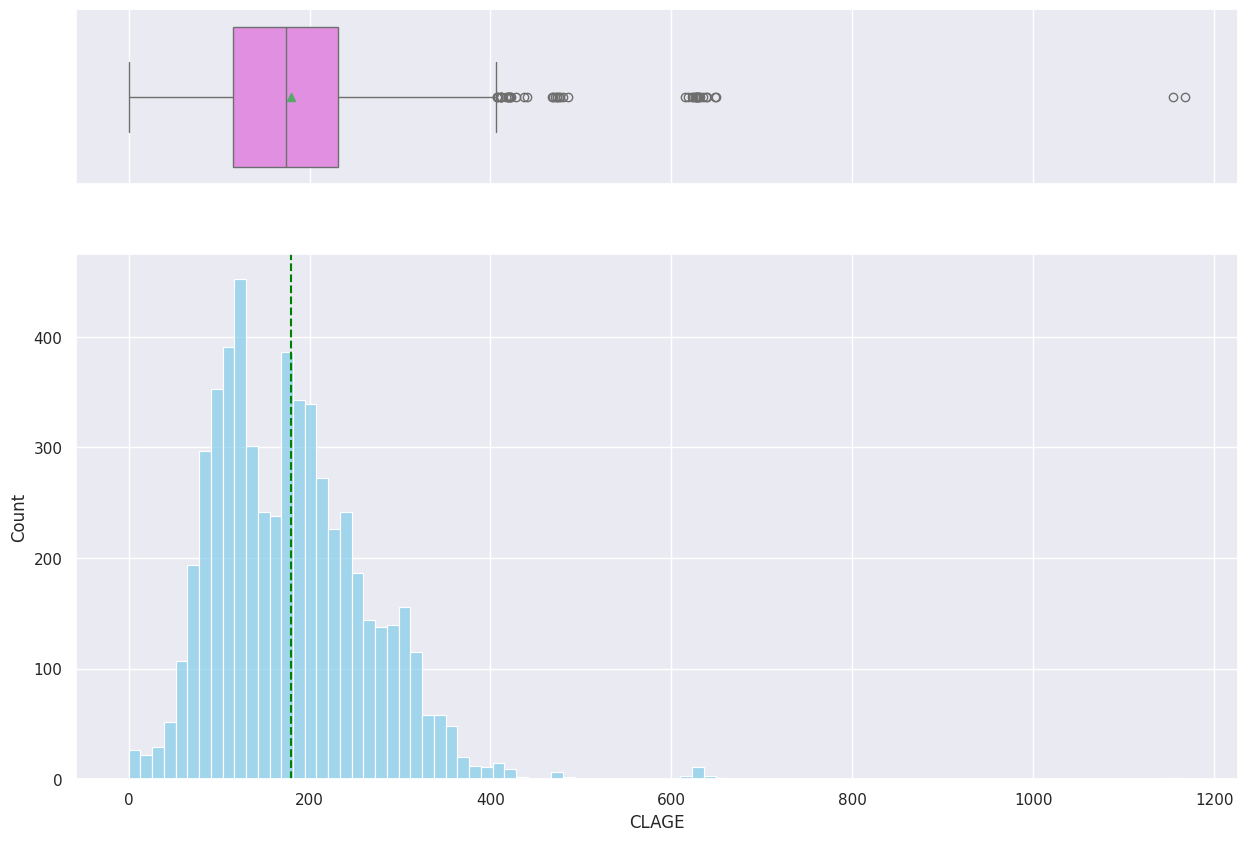

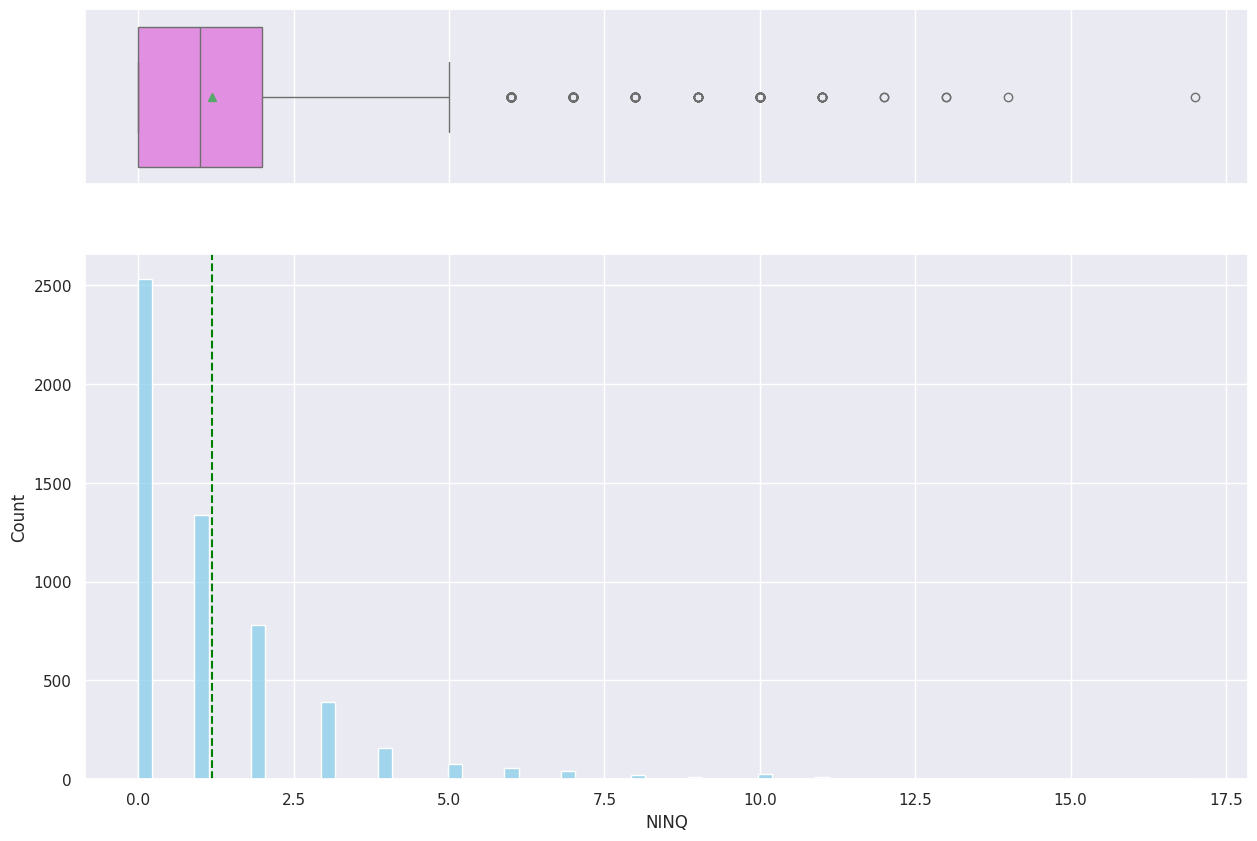

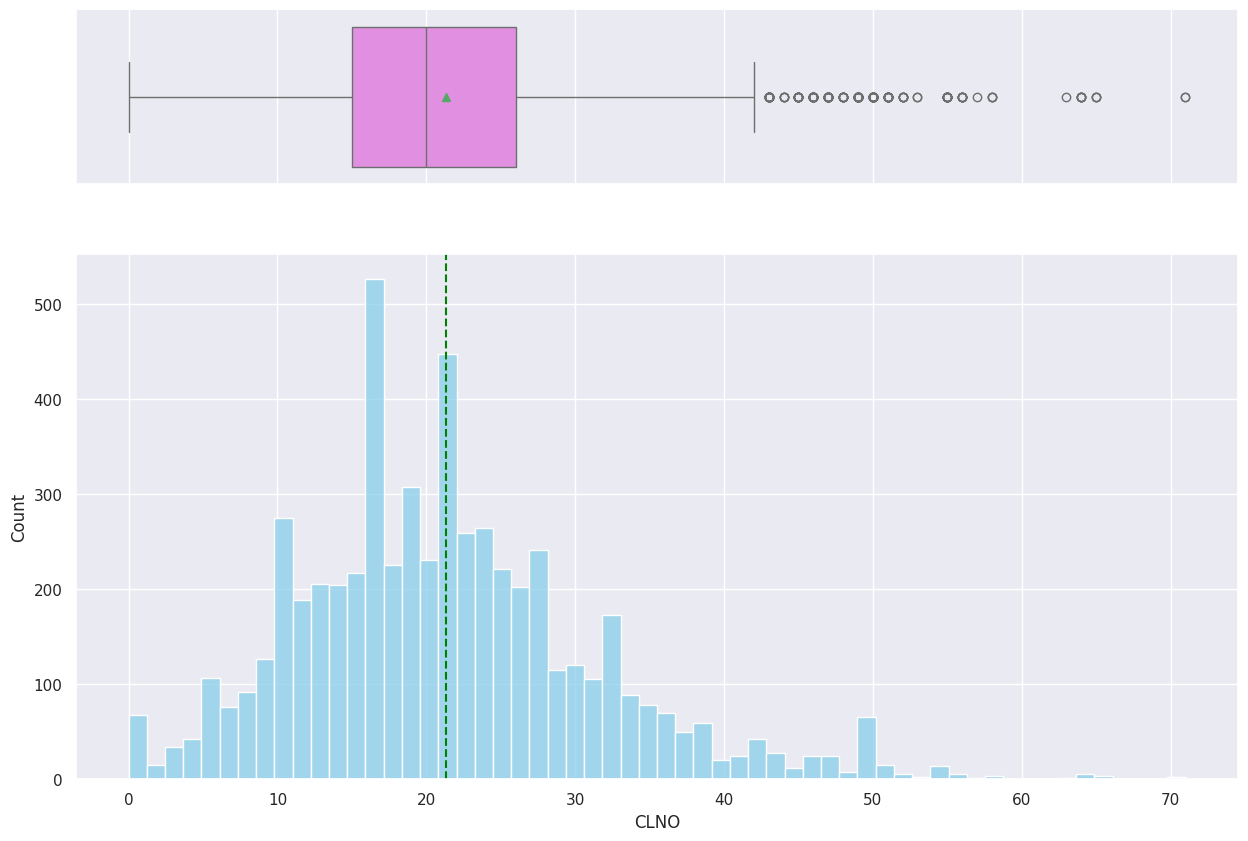

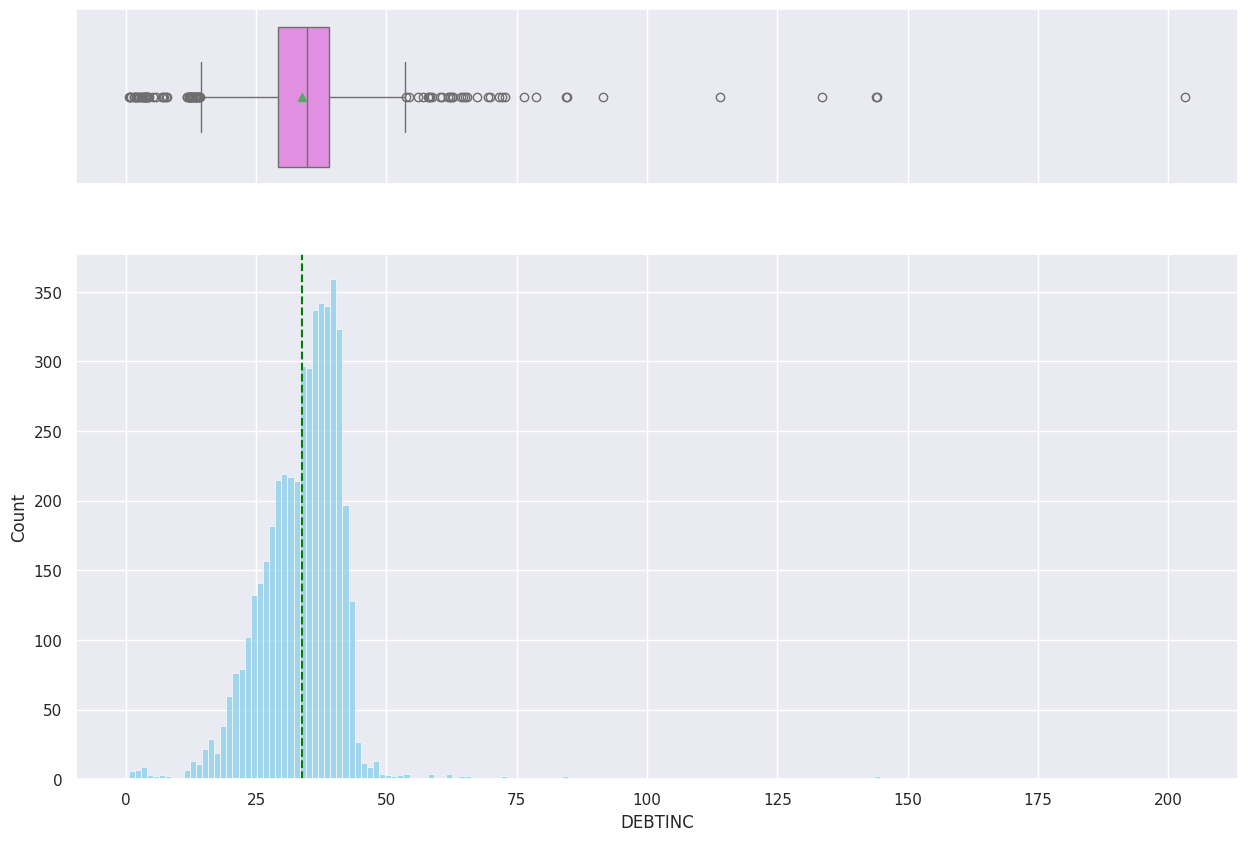

In [ ]:
for i in num_cols:
    histogram_boxplot(data[i])

**INSIGHTS**

*   Loan is right skewed with several high value outliers
*  Mortdue is right skewed with numerous outliers.
*   Value is moderately right skewed with high value outliers.
*   YOJ is highly right skewed with extreme values.
*   DEROG and DELINQ are discrete variables that are right-skewed and contain some outliers.
*   Clage has two seperate peaks and appears bimodial.


*  NINQ is right-skewed with a few outliers.
*  CLNO appears a bit moderately right skewed.


*   DEBTINC appears approximately normally distributed












# **UNIVARIATE ANALYSIS - CATEGORICAL DATA**


In [ ]:
# bar plot indicating percent for each category
def perc_on_bar(plot, feature):
   total_count_in_plot = sum(p.get_width() for p in plot.patches)
   for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width() / total_count_in_plot)

        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        plot.annotate(percentage, (x, y), size=12, ha='left', va='center')

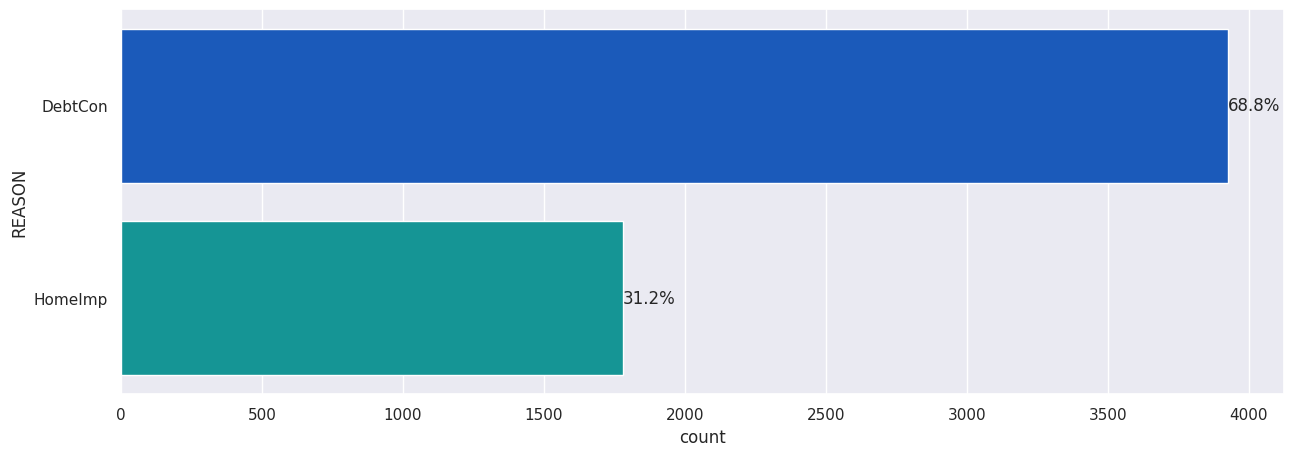

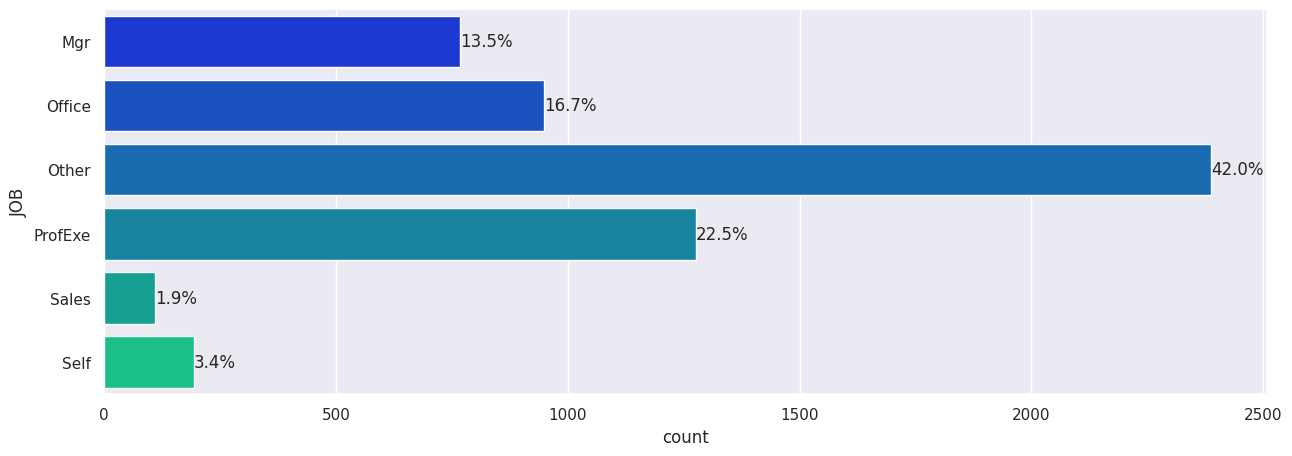

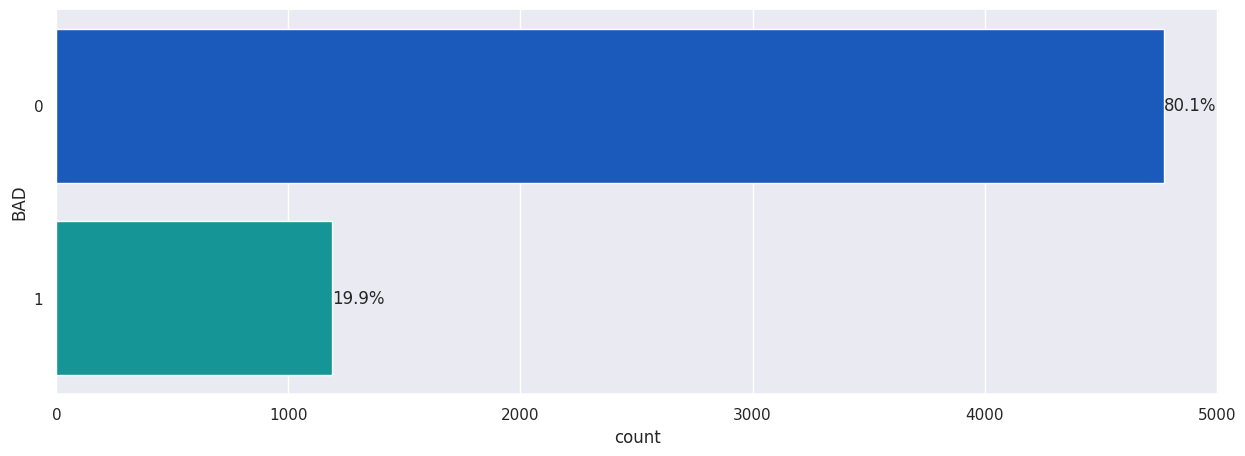

In [ ]:
#building barplot for DELINQ
for i in cols:
    plt.figure(figsize=(15,5))
    ax = sns.countplot(data[i],palette='winter')
    perc_on_bar(ax,data[i])


**Insights**

- DELINQ isn't a categorical variable.
- The variable JOB seems to follow a normal distribution.
- The other two variables REASON and BAD are just 80-20 and 70-30 respectively.



## **Bivariate Analysis**

<Axes: xlabel='BAD', ylabel='DEBTINC'>

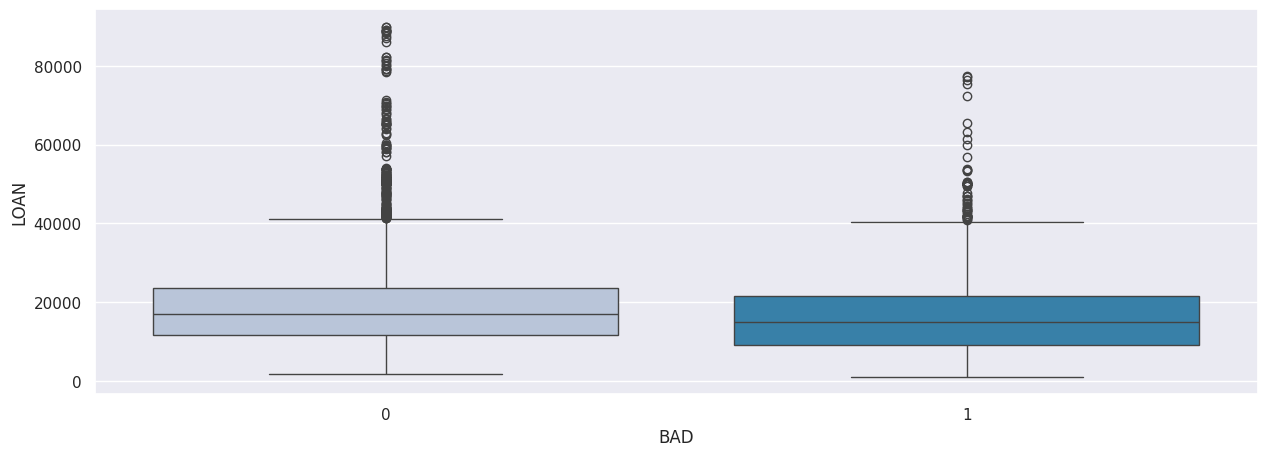

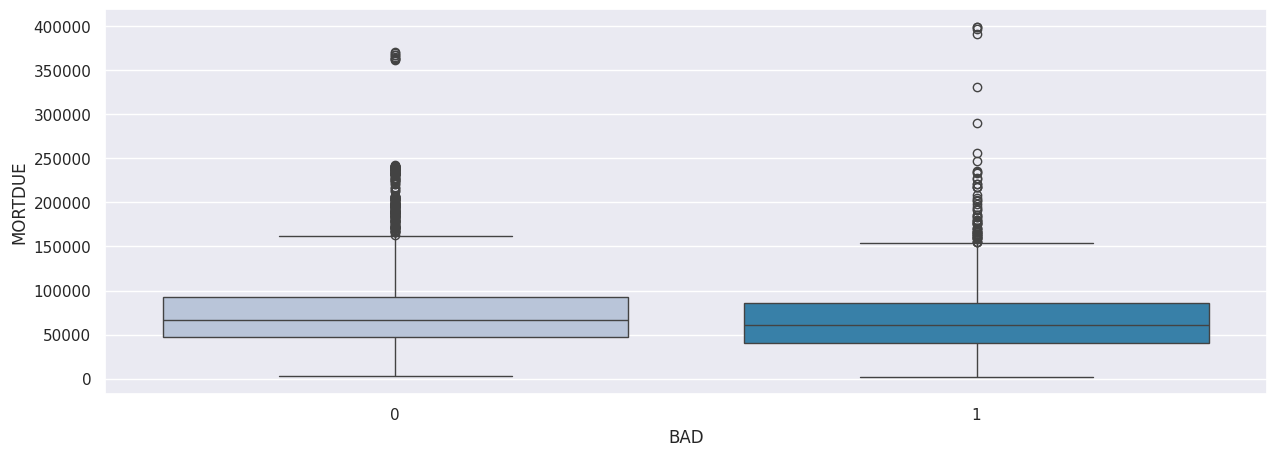

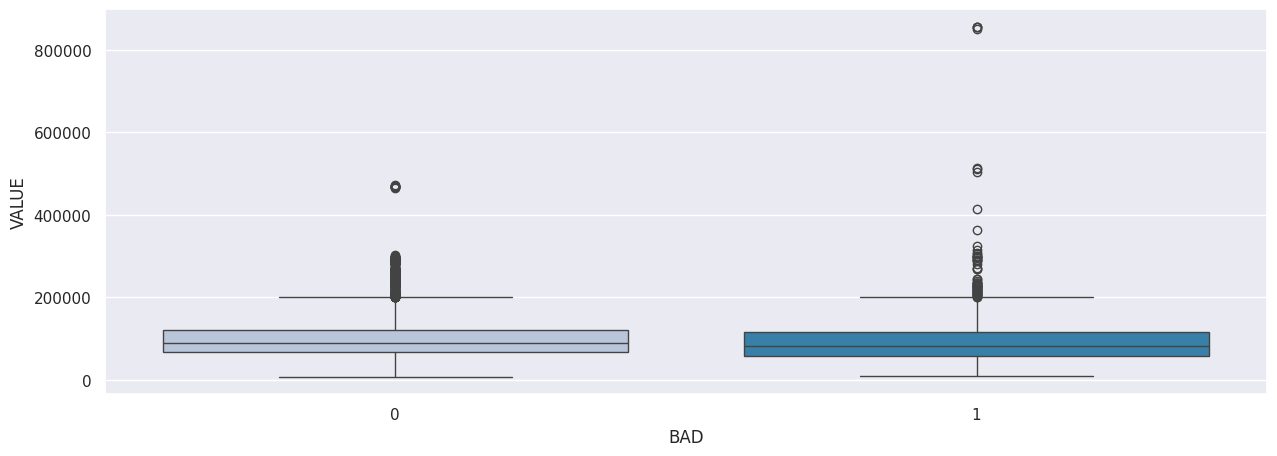

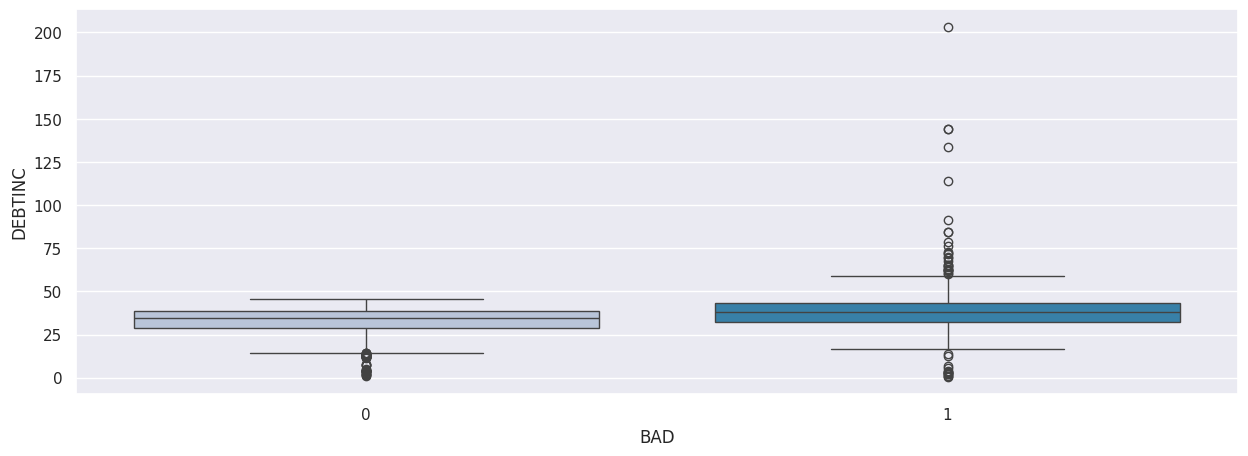

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(x=data["BAD"], y=data['LOAN'], palette="PuBu")
plt.figure(figsize=(15,5))
sns.boxplot(x=data["BAD"], y=data['MORTDUE'], palette="PuBu")
plt.figure(figsize=(15,5))
sns.boxplot(x=data["BAD"], y=data['VALUE'], palette="PuBu")
plt.figure(figsize=(15,5))
sns.boxplot(x=data["BAD"], y=data['DEBTINC'], palette="PuBu")

**Insights**

* **BAD vs LOAN:** The distribution of loan amounts appears similar for both defaulters and non-defaulters, suggesting that loan amount alone may not be a strong differentiating factor.
* **BAD vs MORTDUE:** The amount due on the existing mortgage shows a comparable distribution across both groups, indicating little variation based on default status.
* **BAD vs VALUE:** The property values of defaulters and non-defaulters appear largely similar, suggesting no clear relationship between property value and loan default.
* **BAD vs DEBTINC:** The debt-to-income ratio exhibits substantial overlap between the two groups, indicating that this variable alone may not effectively distinguish defaulters from non-defaulters.


 **Bivariate Analysis: Two Continuous Variables**

<Axes: xlabel='VALUE', ylabel='DEBTINC'>

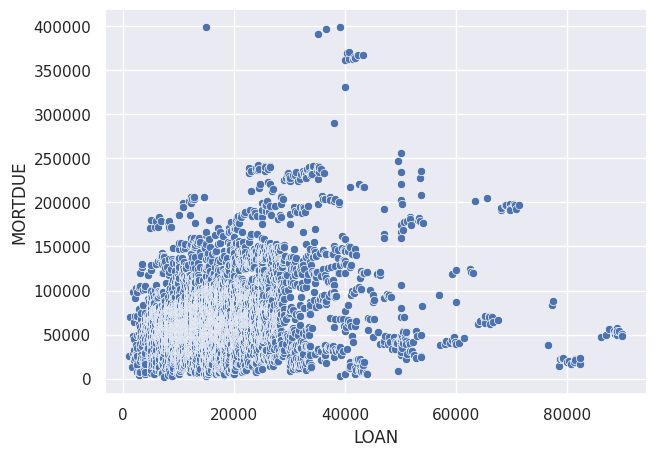

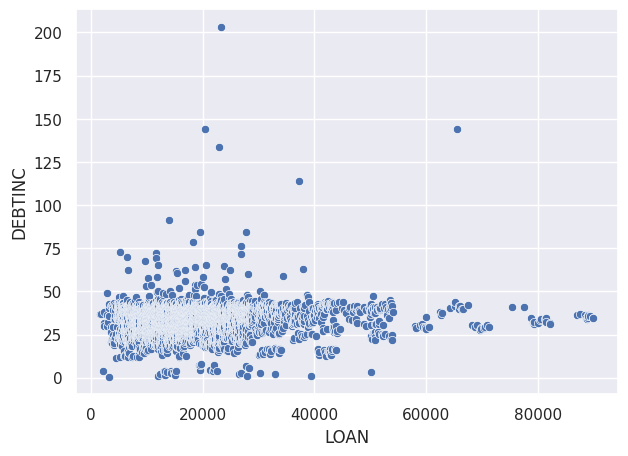

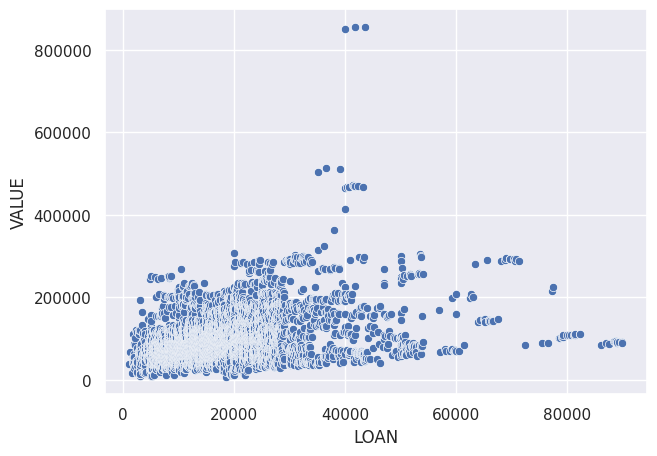

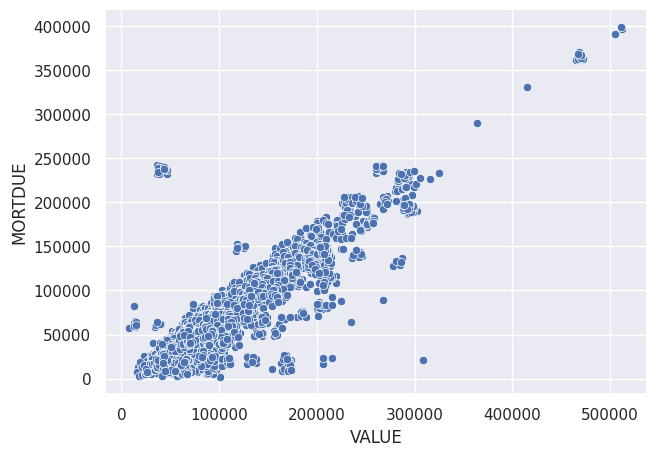

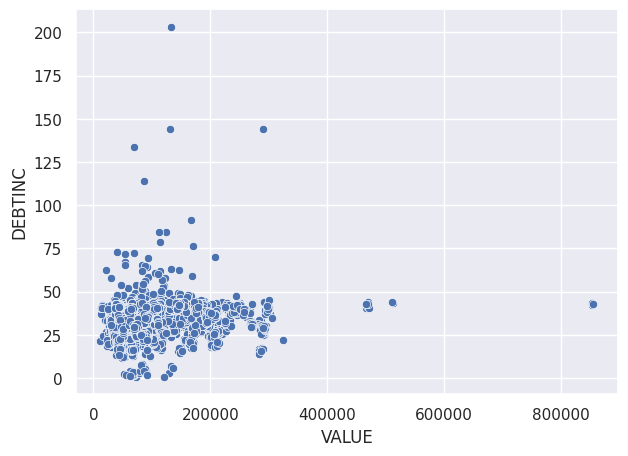

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=data["LOAN"], y=data['MORTDUE'], palette="deep")
plt.figure(figsize=(7,5))
sns.scatterplot(x=data["LOAN"], y=data['DEBTINC'], palette="deep")
plt.figure(figsize=(7,5))
sns.scatterplot(x=data["LOAN"], y=data['VALUE'], palette="deep")
plt.figure(figsize=(7,5))
sns.scatterplot(x=data["VALUE"], y=data['MORTDUE'], palette="deep")
plt.figure(figsize=(7,5))
sns.scatterplot(x=data["VALUE"], y=data['DEBTINC'], palette="deep")


**Insights:**

- There is a linear correlation between the variables VALUE and MORTDUE.
- There is no linear correlation between any other pair of variables.

### **Bivariate Analysis:  BAD vs Categorical Variables**


In [ ]:
#stacked bar chart for categorical column
def stacked_plot(x):
    sns.set(palette='nipy_spectral')
    tab1 = pd.crosstab(x,data['BAD'],margins=True)
    print(tab1)
    print('-'*120)
    tab = pd.crosstab(x,data['BAD'],normalize='index')
    tab.plot(kind='bar',stacked=True,figsize=(10,5))
    plt.legend(loc='lower left', frameon=False)
    plt.legend(loc="upper left", bbox_to_anchor=(1,1))
    plt.show()

BAD         0     1   All
REASON                   
DebtCon  3183   745  3928
HomeImp  1384   396  1780
All      4567  1141  5708
------------------------------------------------------------------------------------------------------------------------


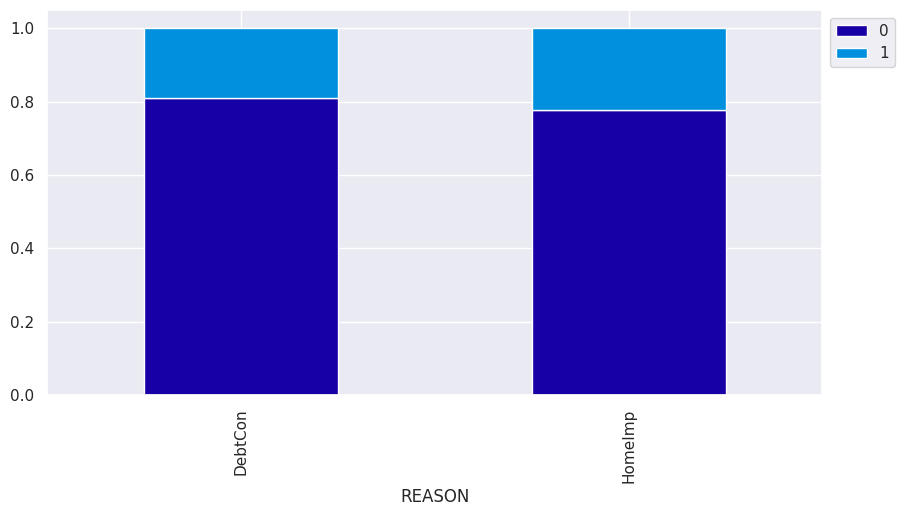

BAD         0     1   All
JOB                      
Mgr       588   179   767
Office    823   125   948
Other    1834   554  2388
ProfExe  1064   212  1276
Sales      71    38   109
Self      135    58   193
All      4515  1166  5681
------------------------------------------------------------------------------------------------------------------------


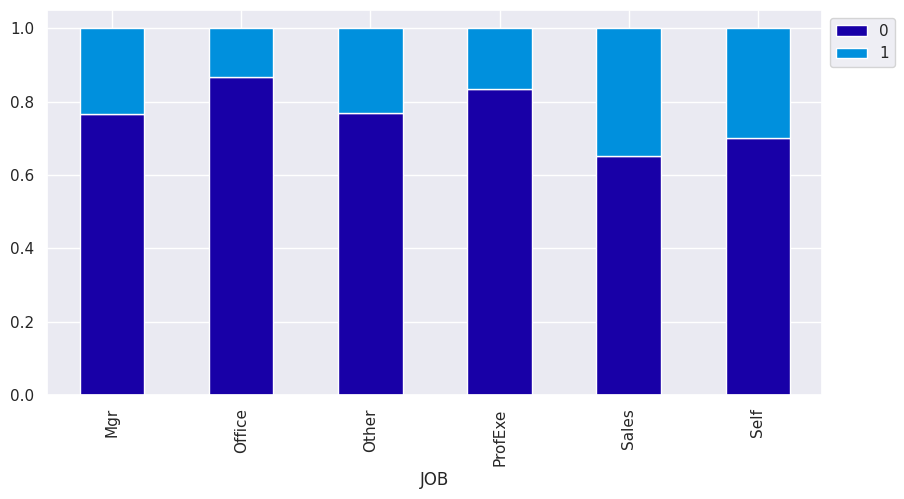

In [ ]:
# Plotting stacked bar plot for BAD and REASON
stacked_plot(data['REASON'])
stacked_plot(data['JOB'])


**Insights**

- In the first chart we can see that independently of the loan's reason 80% are non defaulted and 20% are defaulted clients.
- In the second chart we can see that people in sales has the highest percentage of defaulted loans.
- Office employees and professional executive are the two kind of jobs with the lowest rate of defaulted loans.

**Multi Varient Analysis**

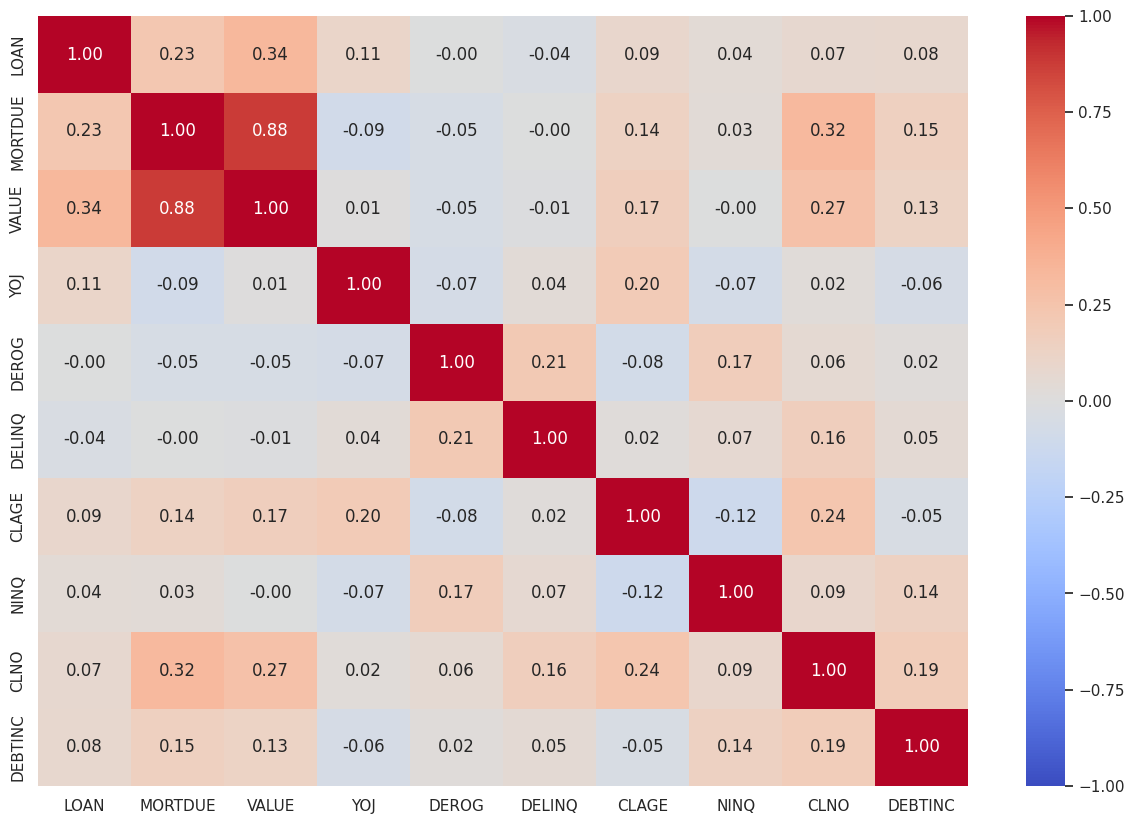

In [ ]:
#correlation haetmap of numerical variables

numerical_col = data.select_dtypes(include=np.number).columns.tolist()

corr = data[numerical_col].corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr , cmap = "coolwarm" , vmax=1 , vmin =-1 ,
            fmt=".2f", annot=True ,
            xticklabels=corr.columns,
            yticklabels=corr.columns);

In [ ]:
#building pairplot for data

sns.pairplot(data , hue='BAD')

Output hidden; open in https://colab.research.google.com to view.

**TREATING OUTLIERS**

In [ ]:
def treat_outliers(df, col):
  Q1=df[col].quantile(q=.25)
  Q3=df[col].quantile(q=.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
  df[col]=np.clip(df[col] , lower_limit, upper_limit)

  return df


def treat_outliers_all(df, col_list):

  for c in col_list:
    df=treat_outliers(df,c)

  return df



In [ ]:
df_raw = data.copy()

numerical_col = df_raw.select_dtypes(include=np.number).columns.tolist()


df_raw = treat_outliers_all(df_raw, numerical_col)

In [ ]:
df

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882



#### Adding new columns in the dataset for each column which has missing values

In [ ]:

#For each column we create a binary flag for the row, if there is missing value in the row, then 1 else 0.
def add_binary_flag(df,col):

    new_col = str(col)
    new_col += '_missing_values_flag'
    df[new_col] = df[col].isna()
    return df

In [ ]:
 #list of columns that has missing values in it
missing_col = [col for col in df.columns if df[col].isnull().any()]

for colmn in missing_col:
    add_binary_flag(df,colmn)


 Filling missing values in numerical columns with median and mode in categorical variables

In [ ]:
#select numeric columns
num_data = df.select_dtypes('number')
# select string and object columns
cat_data = df.select_dtypes(include=['category', 'object']).columns.tolist()

#fill missing value in numerical columns with median
for col in num_data.columns:
    df[col].fillna(df[col].median(), inplace=True)

#fill missing value in object columns with mode
for column in cat_data:
    mode = df[column].mode()[0]
    df[column] = df[column].fillna(mode)

In [ ]:
df.isnull().sum()

,0
BAD,0
LOAN,0
MORTDUE,0
VALUE,0
REASON,0
JOB,0
YOJ,0
DEROG,0
DELINQ,0
CLAGE,0


In [ ]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,...,VALUE_missing_values_flag,REASON_missing_values_flag,JOB_missing_values_flag,YOJ_missing_values_flag,DEROG_missing_values_flag,DELINQ_missing_values_flag,CLAGE_missing_values_flag,NINQ_missing_values_flag,CLNO_missing_values_flag,DEBTINC_missing_values_flag
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,...,False,False,False,False,False,False,False,False,False,True
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,...,False,False,False,False,False,False,False,False,False,True
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,...,False,False,False,False,False,False,False,False,False,True
3,1,1500,65019.0,89235.5,DebtCon,Other,7.0,0.0,0.0,173.466667,...,True,True,True,True,True,True,True,True,True,True
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BAD                          5960 non-null   int64  
 1   LOAN                         5960 non-null   int64  
 2   MORTDUE                      5960 non-null   float64
 3   VALUE                        5960 non-null   float64
 4   REASON                       5960 non-null   object 
 5   JOB                          5960 non-null   object 
 6   YOJ                          5960 non-null   float64
 7   DEROG                        5960 non-null   float64
 8   DELINQ                       5960 non-null   float64
 9   CLAGE                        5960 non-null   float64
 10  NINQ                         5960 non-null   float64
 11  CLNO                         5960 non-null   float64
 12  DEBTINC                      5960 non-null   float64
 13  MORTDUE_missing_va

DROPPING MISSING VALUE FLAGS

In [ ]:
#creating a list of bool features
bool_cols = df.select_dtypes(['bool']).columns.tolist()

#droping missing value flags
X = df.drop(columns = bool_cols)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5960 non-null   float64
 3   VALUE    5960 non-null   float64
 4   REASON   5960 non-null   object 
 5   JOB      5960 non-null   object 
 6   YOJ      5960 non-null   float64
 7   DEROG    5960 non-null   float64
 8   DELINQ   5960 non-null   float64
 9   CLAGE    5960 non-null   float64
 10  NINQ     5960 non-null   float64
 11  CLNO     5960 non-null   float64
 12  DEBTINC  5960 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


# **DATA PREPARATION**

Seperating target variables from other variables

In [ ]:
# Separating the target variable and other variables
Y = X.BAD
X = X.drop(columns = ['BAD'])
# Creating dummy variables for the categorical variables
# list of columns for which we need to create the dummy variables
to_get_dummies_for = ['REASON', 'JOB']

# Creating dummy variables
X = pd.get_dummies(data = X, columns = to_get_dummies_for, drop_first = True)

SCALING THE DATA

In [ ]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

Splitting the data into training and testing set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size = 0.3, random_state = 1, stratify = Y)

Model evaluation criterion

In [ ]:
def metric_score(actual , predicted):
  print(classification_report(actual, predicted))
  cm = confusion_matrix(actual, predicted)
  plt.figure(figsize=(8,5))
  sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Eligible', 'Eligible'], yticklabels=['Not Eligible', 'Eligible'])
  plt.ylabel('Actual')
  plt.xlabel('Predicted')
  plt.show()

LOGISTIC REGRESSION MODEL

In [ ]:
lg = LogisticRegression()
lg.fit(x_train, y_train)

LogisticRegression()

              precision    recall  f1-score   support

           0       0.85      0.97      0.91      3340
           1       0.72      0.34      0.46       832

    accuracy                           0.84      4172
   macro avg       0.79      0.65      0.68      4172
weighted avg       0.83      0.84      0.82      4172



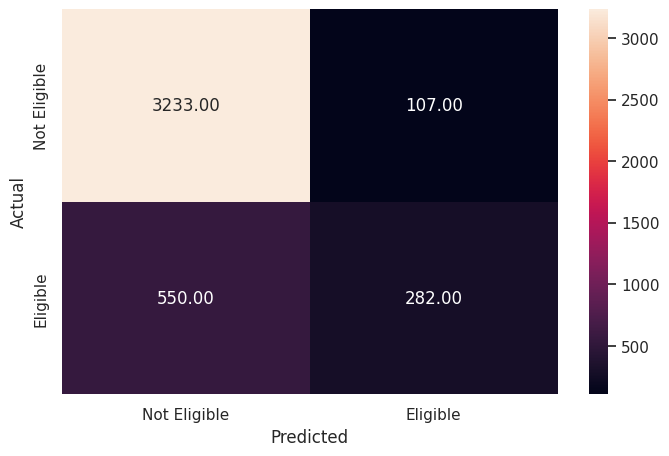

In [ ]:
# check the performance on training dataset
y_pred_train = lg.predict(x_train)
metric_score(y_train, y_pred_train)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1431
           1       0.70      0.28      0.40       357

    accuracy                           0.83      1788
   macro avg       0.77      0.63      0.65      1788
weighted avg       0.81      0.83      0.80      1788



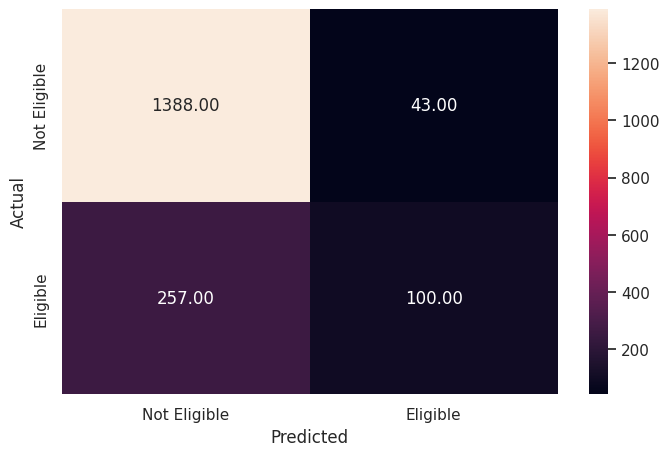

In [ ]:
#check the performance on testing dataset
y_pred_test = lg.predict(x_test)
metric_score(y_test, y_pred_test)

**Insights**

* The Logistic Regression model achieves an **accuracy of 84% on the training set and 83% on the test set**, indicating consistent performance and good generalization.
* The model performs well in identifying **non-defaulters (Class 0)**, achieving a recall of **97%** on both the training and testing datasets.
* For **defaulters (Class 1)**, the recall is **34% on the training set and 28% on the test set**, indicating that a large proportion of actual defaulters are misclassified as non-defaulters.
* The similar performance on the training and testing datasets suggests that the model is **not overfitting**.
* Although the overall accuracy is good, the low recall for the default class indicates that the model is less effective at identifying customers who are likely to default. Improving the recall for Class 1 should therefore be the primary objective.


In [ ]:
#printing the coefficients of logistic regression
cols = X_scaled.columns
coef_lg = lg.coef_
pd.DataFrame(coef_lg,columns = cols).T.sort_values(by = 0, ascending = False)

,0
DELINQ,0.853720
DEBTINC,0.537715
DEROG,0.485888
NINQ,0.241173
VALUE,0.220364
REASON_HomeImp,0.123781
JOB_Sales,0.099452
JOB_Self,0.091951
JOB_ProfExe,-0.026351
JOB_Other,-0.032524


**Insights:**

**Features positively associated with the probability of loan default are:** DELINQ (strongest positive association), DEBTINC, DEROG, NINQ, VALUE, REASON_HomeImp, JOB_Sales, JOB_Self.

**Features negatively associated with the probability of loan default are:** CLAGE (strongest negative association), MORTDUE, LOAN, JOB_Office, CLNO, YOJ, JOB_Other, JOB_ProfExe.

* A positive coefficient indicates that an increase in the feature is associated with a higher probability of loan default.
* A negative coefficient indicates that an increase in the feature is associated with a lower probability of loan default.
* DELINQ has the strongest positive association with loan default, while CLAGE has the strongest negative association among all the features.


The coefficients of the logistic regression model give us the log of odds, which is hard to interpret in the real world. We can convert the log of odds into odds by taking its exponential.

In [ ]:
#finding log of odds and adding the odds to a dataframe and sorting the values

odds = np.exp(lg.coef_[0])
pd.DataFrame(odds, columns = ['Odds'], index = cols).sort_values(by = 'Odds', ascending = False)

,Odds
DELINQ,2.348367
DEBTINC,1.712091
DEROG,1.625619
NINQ,1.272742
VALUE,1.246530
REASON_HomeImp,1.131768
JOB_Sales,1.104566
JOB_Self,1.096311
JOB_ProfExe,0.973994
JOB_Other,0.967999


**Insights:**

* **DELINQ** has the highest odds ratio, while **CLAGE** has the lowest.
* Higher **DELINQ, DEBTINC, DEROG, and NINQ** increase default odds, whereas higher **CLAGE, MORTDUE, LOAN, and YOJ** reduce them.


**PRECISION RECALL CURVE FOR LOGISTIC REGRESSION**

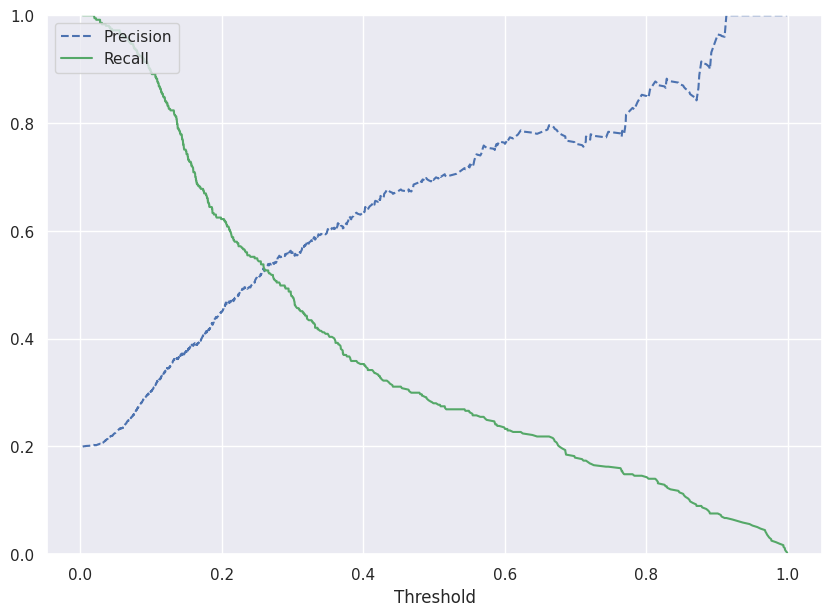

In [ ]:
y_scores_lg = lg.predict_proba(x_test)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_lg[:,1])
plt.figure(figsize = (10, 7))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()


Here we can see that the threshold value lies aroud 0.28.

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      3340
           1       0.55      0.56      0.55       832

    accuracy                           0.82      4172
   macro avg       0.72      0.72      0.72      4172
weighted avg       0.82      0.82      0.82      4172



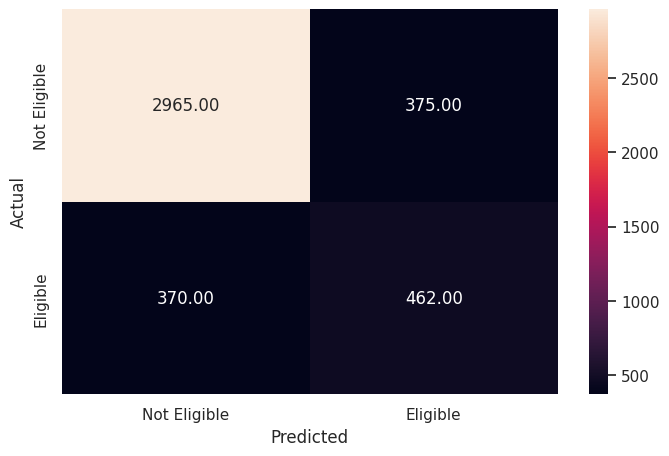

In [ ]:
#performance of the model at htis threshold for training dataset
optimal_threshold1 = .28
y_pred_train = lg.predict_proba(x_train)
metric_score(y_train, y_pred_train[:, 1] > optimal_threshold1)


              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1431
           1       0.55      0.50      0.53       357

    accuracy                           0.82      1788
   macro avg       0.72      0.70      0.71      1788
weighted avg       0.81      0.82      0.82      1788



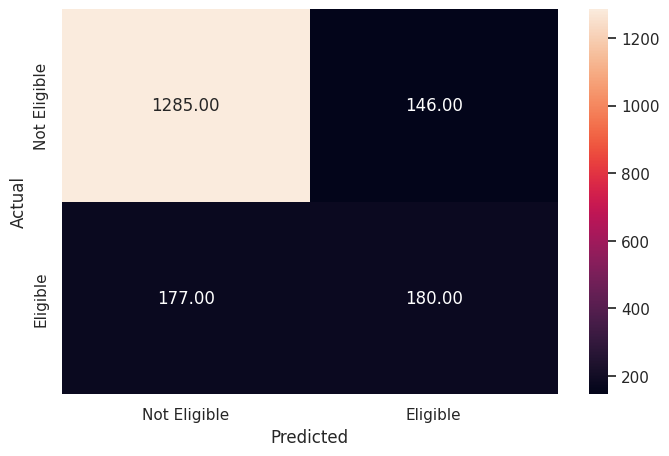

In [ ]:
#perfromance of the mdoel at threshold on testing dataset
optimal_threshold1 = .28
y_pred_test = lg.predict_proba(x_test)
metric_score(y_test, y_pred_test[:, 1] > optimal_threshold1)


**Observations:**

* The model performs similarly on the training and testing datasets, indicating good generalization.
* At a threshold of **0.28**, the recall for the default class increases to **56%** on the training set and **50%** on the testing set.
* Precision decreases to **55%**, while the overall accuracy becomes **82%**.
* The threshold of **0.28** provides a better balance between precision and recall for identifying loan defaulters.


# **DECISION TREE MODEL**

In [ ]:
#data preparation for tree-based model
Y = data.BAD
X = data.drop(columns = ['BAD'])

# Creating the list of columns for which we need to create the dummy variables
to_get_dummies_for = ['REASON', 'JOB']

# Creating dummy variables
X = pd.get_dummies(data = X, columns = to_get_dummies_for, drop_first = True)

In [ ]:
X


,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,True,False,True,False,False,False
1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,True,False,True,False,False,False
2,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,True,False,True,False,False,False
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False
4,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,88900,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,False,False,True,False,False,False
5956,89000,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,False,False,True,False,False,False
5957,89200,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,False,False,True,False,False,False
5958,89800,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,False,False,True,False,False,False


splitting the data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1, stratify = Y)

In [ ]:
#defining the decision tree model
dt = DecisionTreeClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 1)

In [ ]:
#fitting Decision tree model
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

checking the performance on training dataset


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



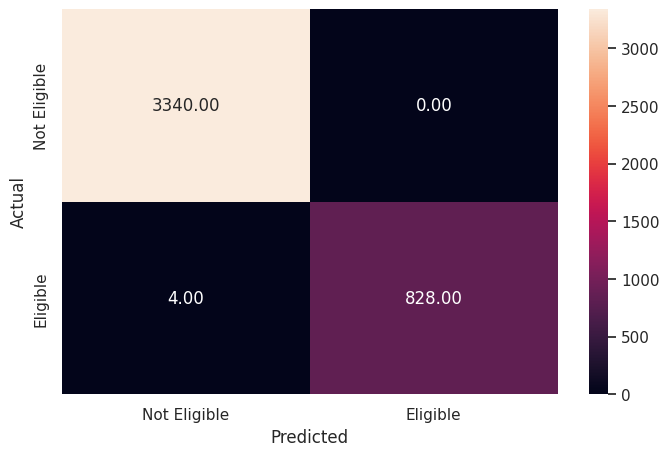

In [ ]:
y_train_pred_dt = dt.predict(x_train)
metric_score(y_train, y_train_pred_dt)

checking the performance on testing dataset

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1431
           1       0.73      0.63      0.67       357

    accuracy                           0.88      1788
   macro avg       0.82      0.78      0.80      1788
weighted avg       0.87      0.88      0.88      1788



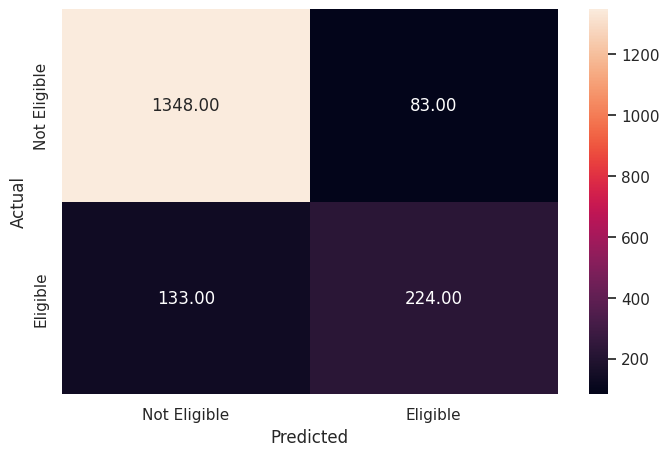

In [ ]:
y_test_pred_dt = dt.predict(x_test)
metric_score(y_test, y_test_pred_dt)

**Insights**

* The Decision Tree achieves **100% accuracy** on the training set but **88% accuracy** on the testing set, indicating **overfitting**.
* The model attains a **recall of 63%** for the default class on the test set, outperforming the Logistic Regression model.
* The test precision of **73%** indicates that most customers predicted as defaulters are correctly classified.
* Overall, the Decision Tree identifies loan defaulters more effectively than the Logistic Regression model, despite showing signs of overfitting.


**Hyperparameter tuning using Grid Search**

<Axes: xlabel='Importance', ylabel='None'>

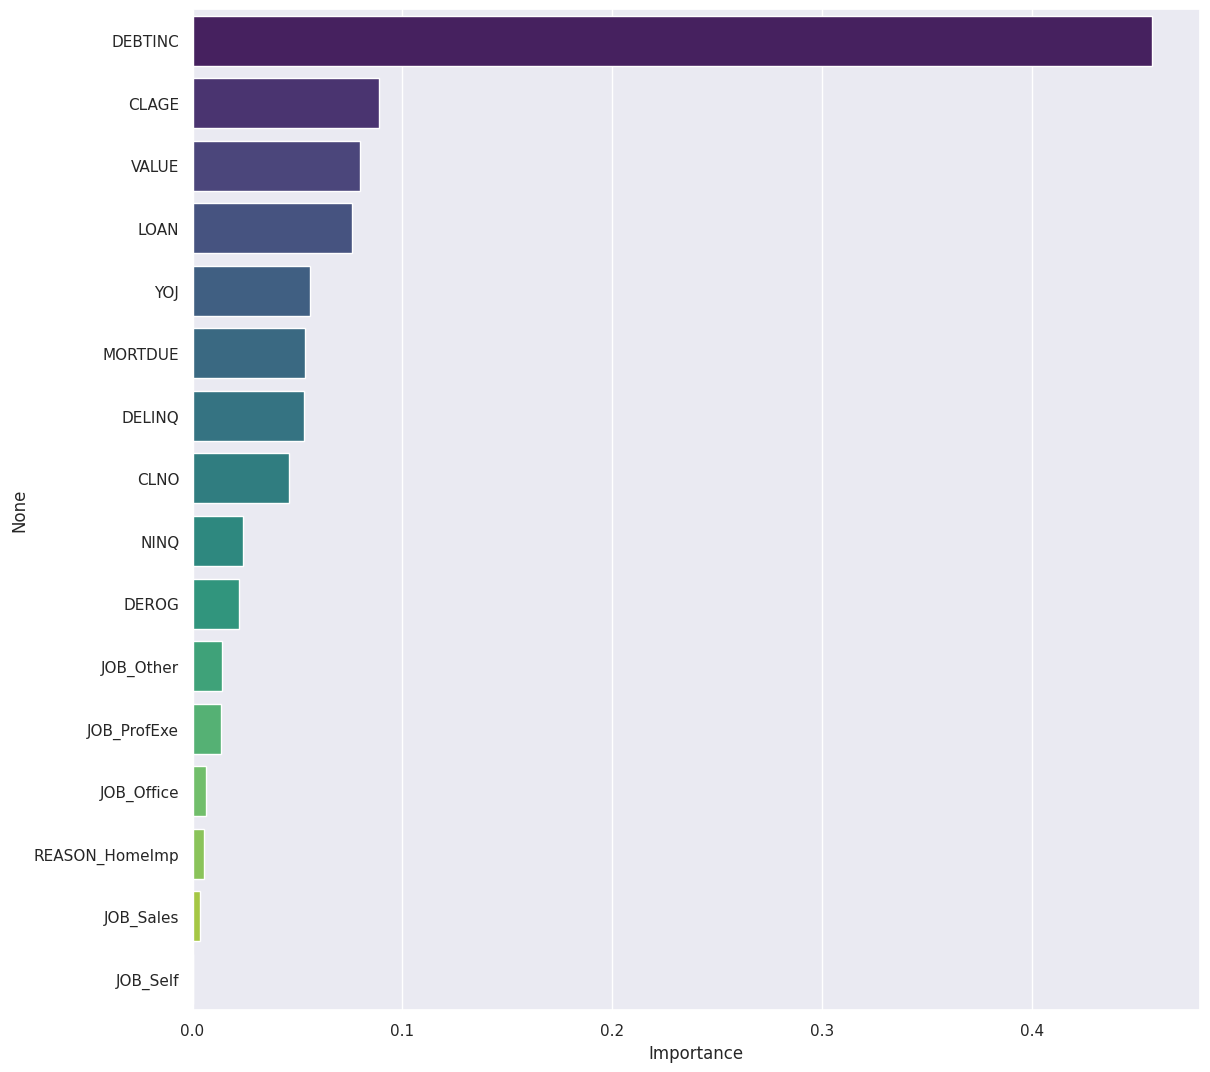

In [ ]:
#plotting the feature importance

importances = dt.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(x=importance_df.Importance, y=importance_df.index, palette='viridis')

**Insights**

* According to the Decision Tree, **DEBTINC** is the most important feature, followed by **CLAGE, VALUE, LOAN, and YOJ**.
* **MORTDUE, DELINQ, CLNO, NINQ, and DEROG** also contribute to the model, while the remaining job and reason-related features have relatively low importance.


Using GridSearchCV for Hyperparameter tuning on the model

In [ ]:
from sklearn.metrics import recall_score
dtree_estimator = DecisionTreeClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state =1)

parameters = {'max_depth': np.arange(2, 7),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

scorer = metrics.make_scorer(recall_score , pos_label =1)

gridCV = GridSearchCV(dtree_estimator, parameters, scoring = scorer, cv = 10)

gridCV = gridCV.fit(x_train, y_train)

dtree_estimator = gridCV.best_estimator_
dtree_estimator.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, max_depth=np.int64(3),
                       min_samples_leaf=20, random_state=1)

Checking performance on training dataset

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      3340
           1       0.61      0.80      0.69       832

    accuracy                           0.86      4172
   macro avg       0.78      0.84      0.80      4172
weighted avg       0.88      0.86      0.87      4172



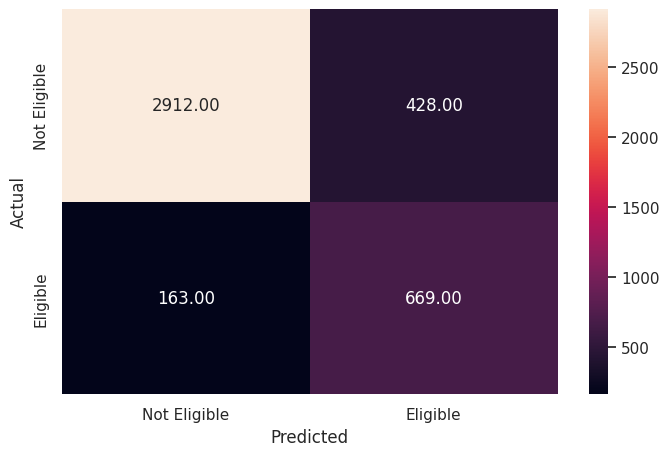

In [ ]:
y_train_pred_dt = dtree_estimator.predict(x_train)
metric_score(y_train, y_train_pred_dt)

Checking the performance on testing dataet

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1431
           1       0.60      0.76      0.67       357

    accuracy                           0.85      1788
   macro avg       0.77      0.82      0.79      1788
weighted avg       0.87      0.85      0.86      1788



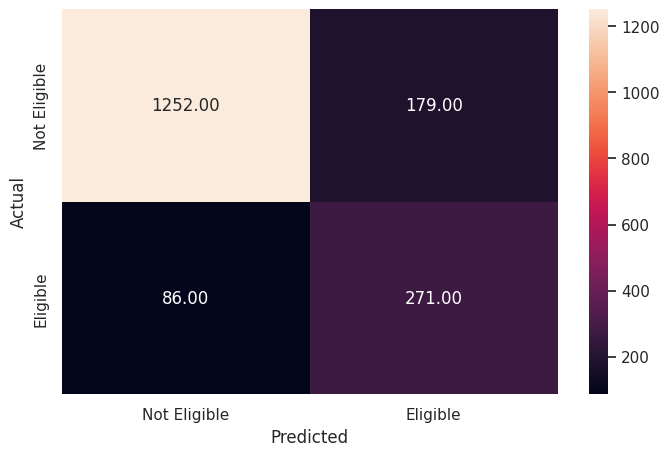

In [ ]:
y_test_pred_dt = dtree_estimator.predict(x_test)
metric_score(y_test, y_test_pred_dt)

**Insights**

* Compared to the default Decision Tree, the tuned model shows lower training performance, indicating reduced overfitting.
* The tuned model achieves similar performance on the training and testing datasets, suggesting better generalization.
* The recall for the default class improves to **80%** on the training set and **76%** on the testing set, allowing the model to identify more actual defaulters.
* The precision for the default class decreases to **61%** on the training set and **60%** on the testing set, indicating an increase in false positives.


<Axes: xlabel='Importance', ylabel='None'>

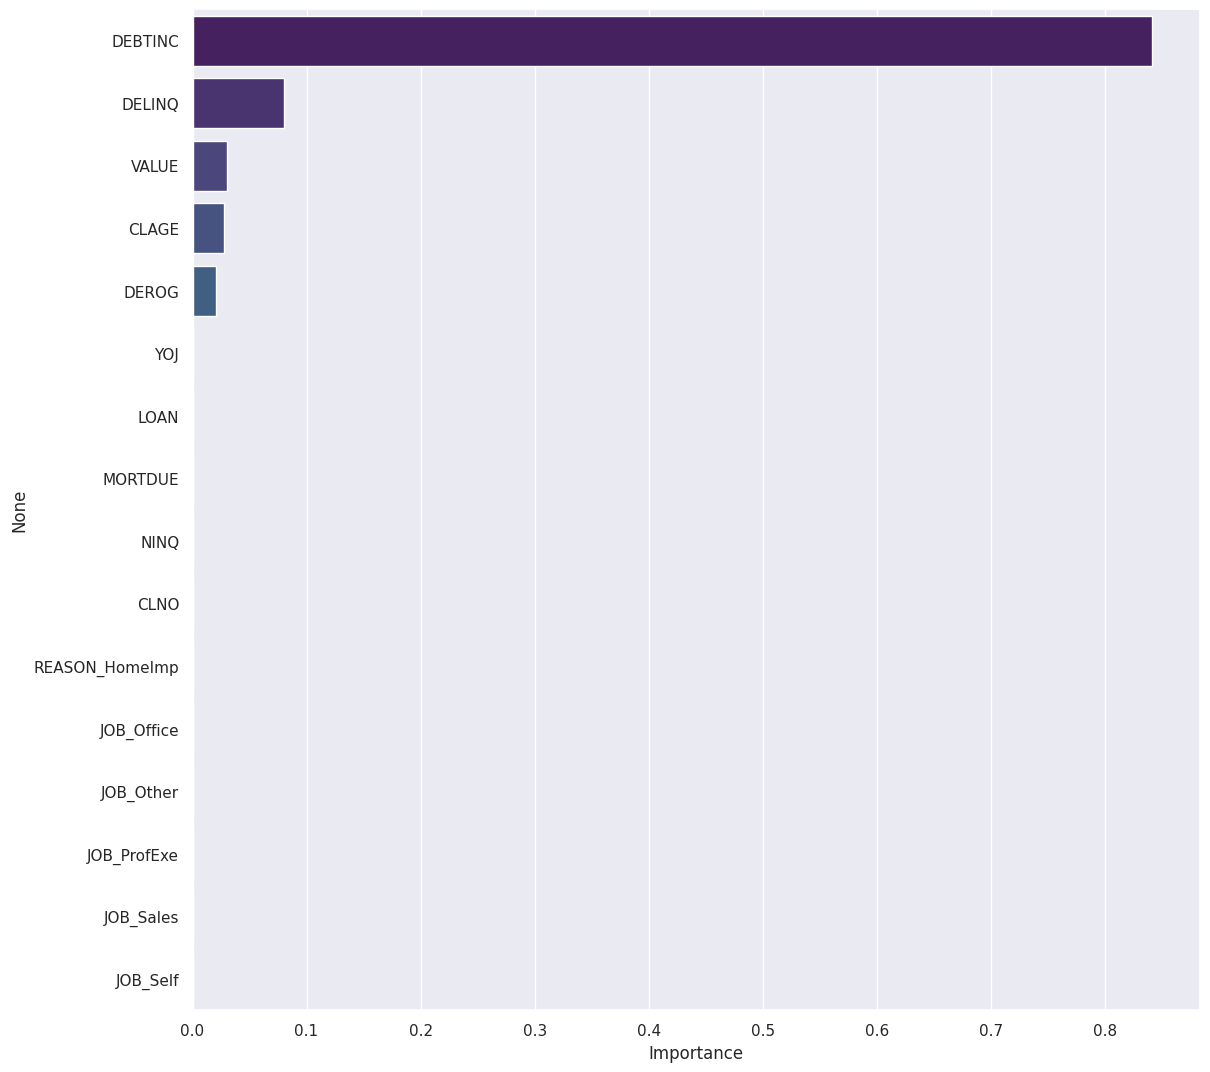

In [ ]:
# feature importance of the tuned decision tree model
importances = dtree_estimator.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(x=importance_df.Importance, y=importance_df.index ,palette='viridis')

**Observations**

* After tuning, the model relies primarily on **DEBTINC**, followed by **DELINQ, VALUE, CLAGE, and DEROG**, while the remaining features contribute very little.
* **DEBTINC** is by far the most influential feature, indicating that the debt-to-income ratio plays the dominant role in predicting loan default.


Plotting the decision tree

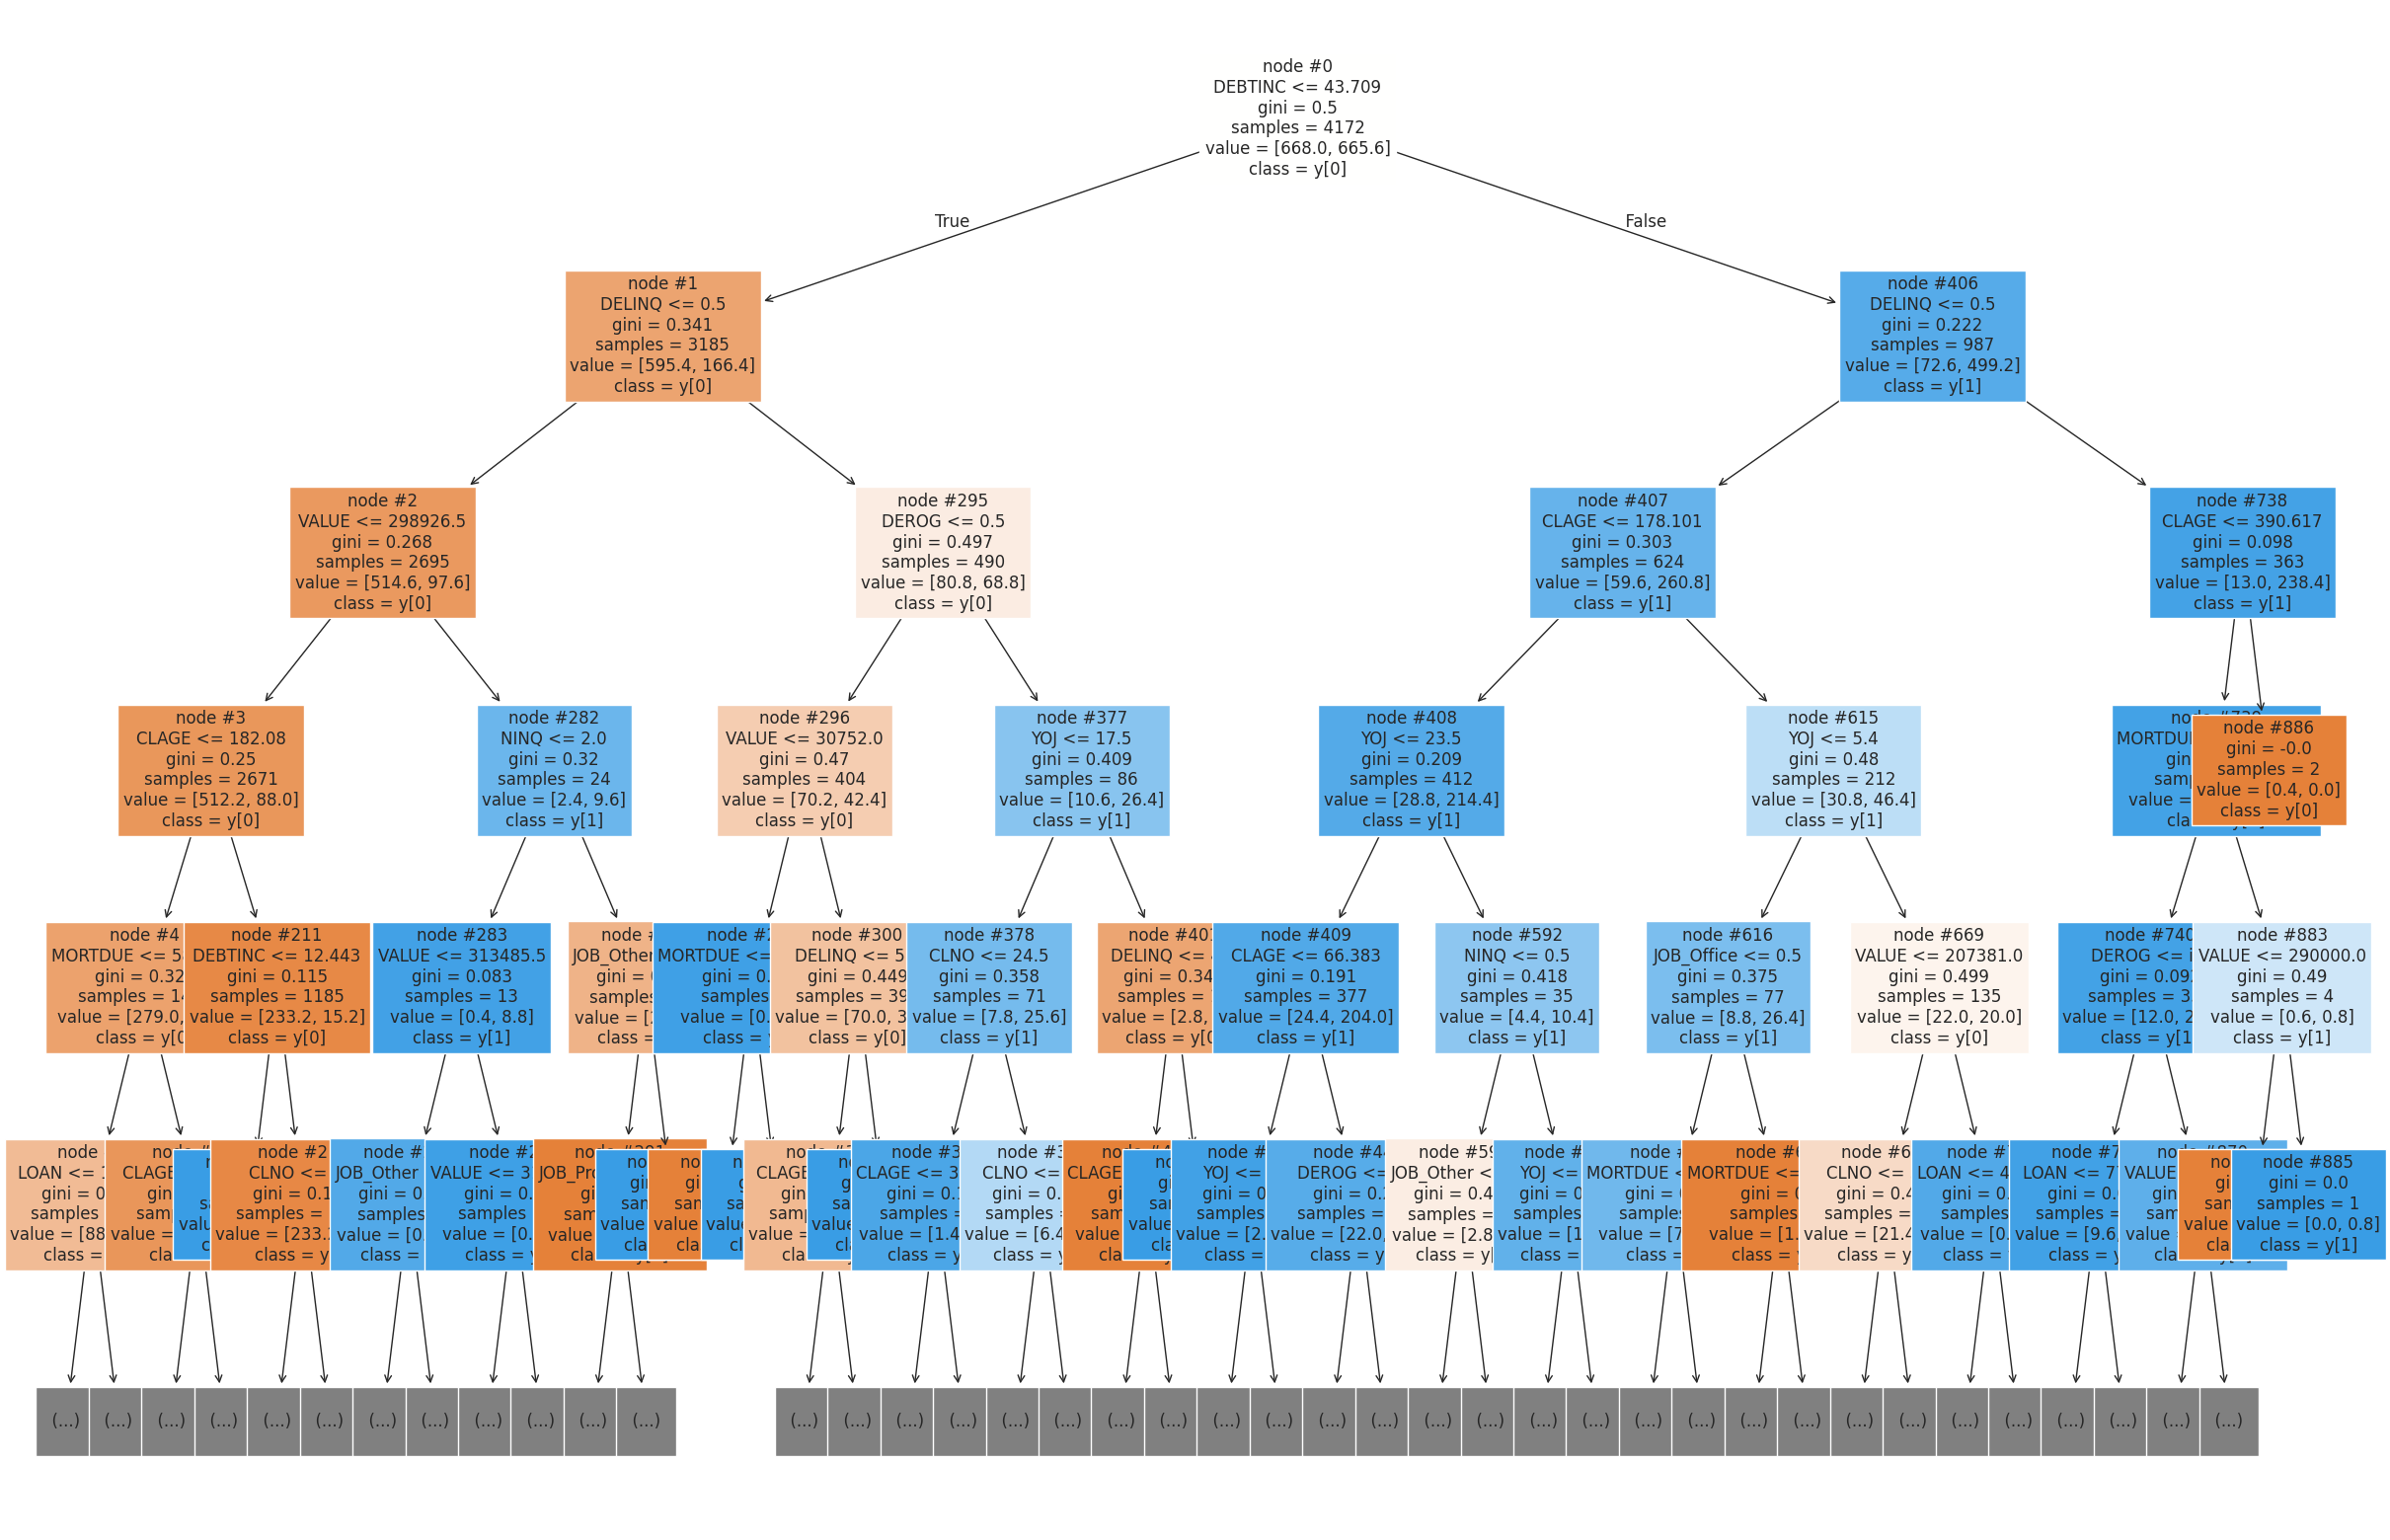

In [ ]:
features = list(X.columns)
plt.figure(figsize = (30, 20))
tree.plot_tree(dt, max_depth = 5, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = True)
plt.show()


**Note:** Blue nodes represent **loan defaulters (y[1])**, while orange nodes represent **non-defaulters (y[0])**. Darker colors indicate a higher number of observations in that node.

**Business Rules**

* If **DEBTINC > 43.7** and **DELINQ > 0.5**, the client has a high chance of defaulting.
* If **DEBTINC > 43.7**, **DELINQ ≤ 0.5**, and **CLAGE ≤ 178.1 months**, the client has a high chance of defaulting.
* If **DEBTINC > 43.7**, **DELINQ ≤ 0.5**, and **CLAGE > 390.6 months**, the client is unlikely to default.
* If **DEBTINC ≤ 43.7**, **DELINQ ≤ 0.5**, and **VALUE ≤ 298,926**, the client is unlikely to default.
* If **DEBTINC ≤ 43.7**, **DELINQ > 0.5**, and **DEROG > 0.5**, the client has a higher chance of defaulting.
* If **DEBTINC ≤ 43.7**, **DELINQ ≤ 0.5**, but **NINQ > 3.2**, the client has a higher chance of defaulting.
* Overall, **DEBTINC** is the primary decision criterion, followed by **DELINQ**, **CLAGE**, **VALUE**, and **DEROG** in determining loan default.


# **RANDOM FOREST CLASSIFIER**

In [ ]:
rf_estimator = RandomForestClassifier(random_state = 1)
rf_estimator.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

Checking the performance on training dataset

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



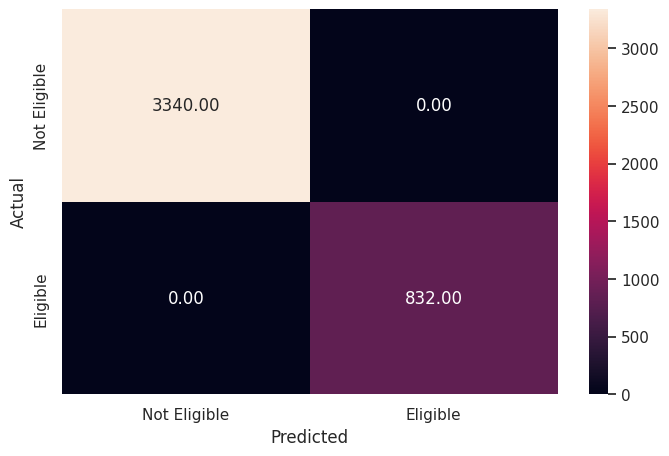

In [ ]:
y_pred_train_rf = rf_estimator.predict(x_train)
metric_score(y_train, y_pred_train_rf)

Checking the performance on testing dataset

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1431
           1       0.84      0.68      0.75       357

    accuracy                           0.91      1788
   macro avg       0.88      0.82      0.85      1788
weighted avg       0.91      0.91      0.91      1788



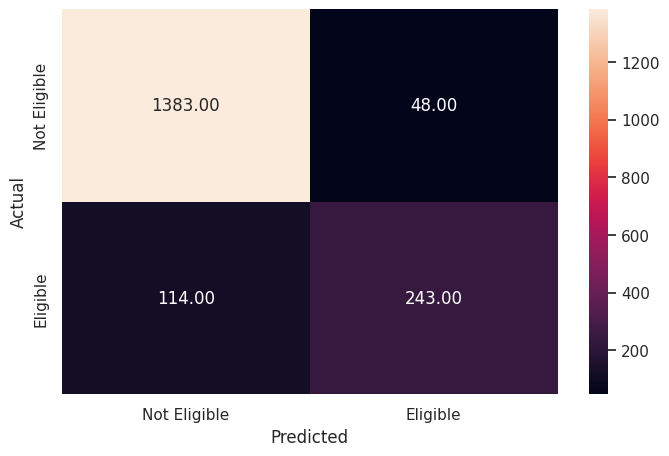

In [ ]:
y_pred_test_rf = rf_estimator.predict(x_test)
metric_score(y_test, y_pred_test_rf)

**Insights**

* The Random Forest model achieves **100% accuracy** on the training set but **91% accuracy** on the testing set, indicating **overfitting**.
* On the testing set, the model achieves a **precision of 84%** and a **recall of 68%** for the default class.
* Compared to the Decision Tree, the Random Forest provides **higher precision and overall accuracy**, while maintaining a good recall for identifying defaulters.


**Building a Random Forest model with class weights**

In [ ]:
rf_estimator = RandomForestClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 1)
rf_estimator.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

Checking the performance on training dataset

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



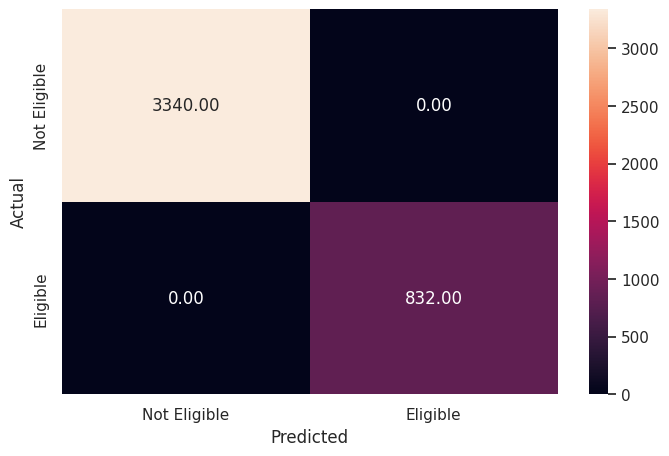

In [ ]:
y_pred_train_rf = rf_estimator.predict(x_train)
metric_score(y_train, y_pred_train_rf)

Checking the performance on testing dataset

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1431
           1       0.85      0.65      0.73       357

    accuracy                           0.91      1788
   macro avg       0.88      0.81      0.84      1788
weighted avg       0.90      0.91      0.90      1788



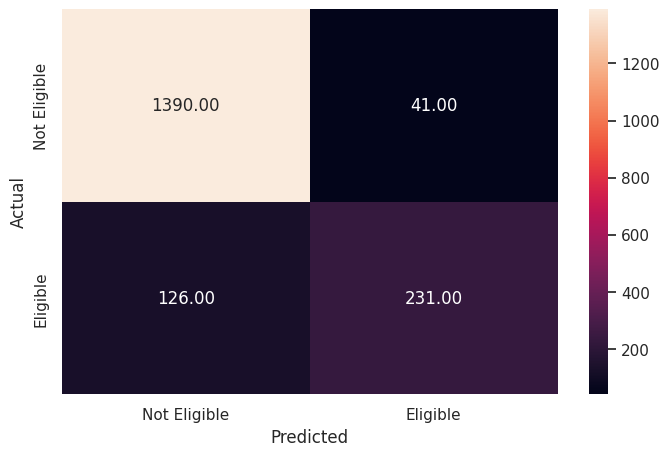

In [ ]:
y_pred_test_rf = rf_estimator.predict(x_test)
metric_score(y_test, y_pred_test_rf)

**Observations**

* The Random Forest model continues to **overfit** the training data, achieving **100% accuracy** on the training set.
* On the testing set, the model achieves **85% precision** and **65% recall** for the default class.
* Compared to the default Random Forest model, the recall decreases from **68% to 65%**, while the precision increases slightly from **84% to 85%**.
* Using `class_weight={0:0.2, 1:0.8}` does not improve the model performance; the default class weights provide better recall for identifying loan defaulters.


Plot of the feature importance of random forest

<Axes: xlabel='Importance', ylabel='None'>

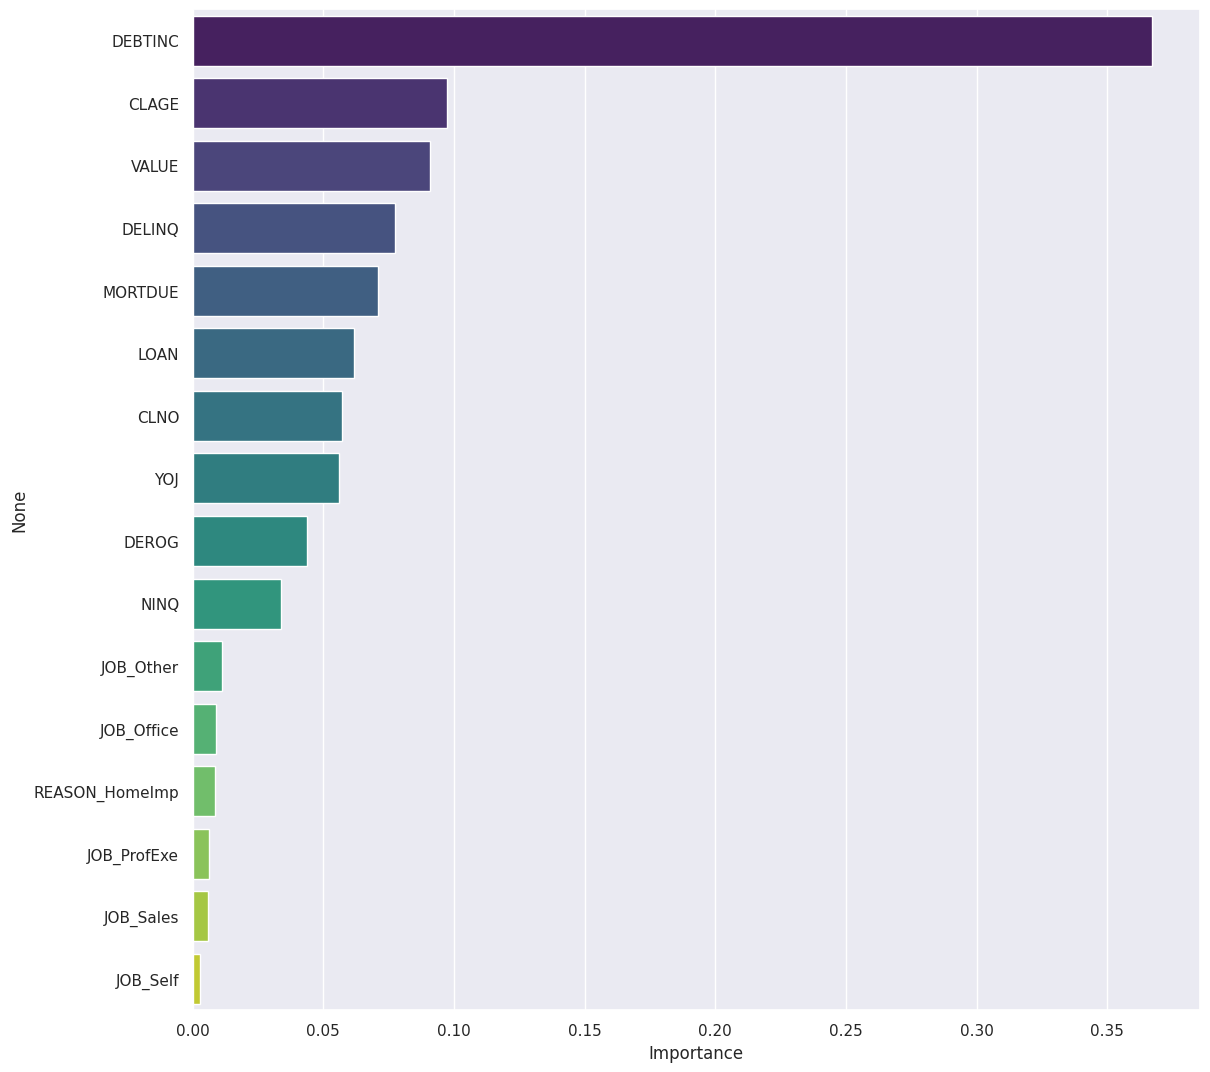

In [ ]:
importances = rf_estimator.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(x=importance_df.Importance, y=importance_df.index, palette='viridis')

**Insights**

* **DEBTINC** is the most important feature, followed by **CLAGE, VALUE, DELINQ, and MORTDUE**, indicating that these variables contribute the most to loan default prediction.
* The remaining features have relatively low importance, suggesting they have a smaller influence on the Random Forest model's predictions.


Tuning the Random Forest

In [ ]:
rf_estimator_tuned = RandomForestClassifier(random_state=1)
params_rf = {
        "n_estimators": [100, 250, 500],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9, 'auto'],
}
scorer = metrics.make_scorer(recall_score, pos_label=1)
gridCV = GridSearchCV(rf_estimator_tuned, params_rf, scoring=scorer, cv=5)

gridCV = gridCV.fit(x_train, y_train)
rf_estimator_tuned = gridCV.best_estimator_
rf_estimator_tuned.fit(x_train, y_train)



RandomForestClassifier(max_features=0.9, min_samples_leaf=np.int64(1),
                       n_estimators=250, random_state=1)

Checking the performance on training dataset

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



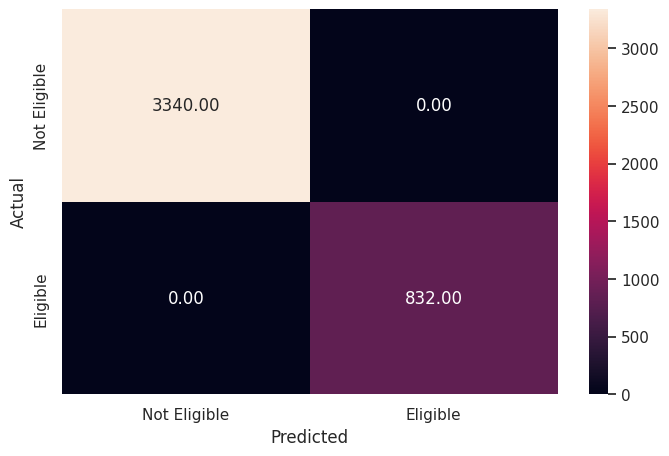

In [71]:
y_pred_train_rf_tuned = rf_estimator_tuned.predict(x_train)
metric_score(y_train, y_pred_train_rf_tuned)

Checking the performance on testing dataset

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1431
           1       0.83      0.71      0.76       357

    accuracy                           0.91      1788
   macro avg       0.88      0.84      0.85      1788
weighted avg       0.91      0.91      0.91      1788



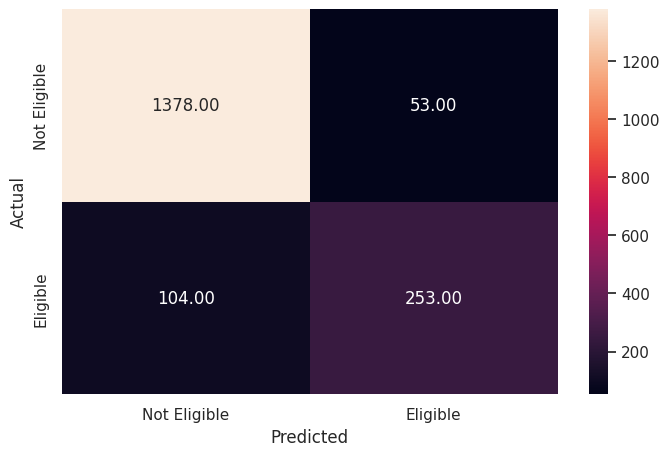

In [72]:
y_pred_test_rf_tuned = rf_estimator_tuned.predict(x_test)
metric_score(y_test, y_pred_test_rf_tuned)

**Insights**

* The tuned Random Forest model continues to **overfit** the training data but performs well on the testing dataset.
* Compared to the default Random Forest, the recall for the default class improves from **68% to 71%**, while the precision decreases slightly from **84% to 83%**.
* The tuned Random Forest achieves a higher recall (**71% vs. 68%**) and comparable precision (**83% vs. 84%**) compared to the tuned Decision Tree, making it the best-performing model overall.


Plotting the feature importance of tuned random forest

<Axes: xlabel='Importance', ylabel='None'>

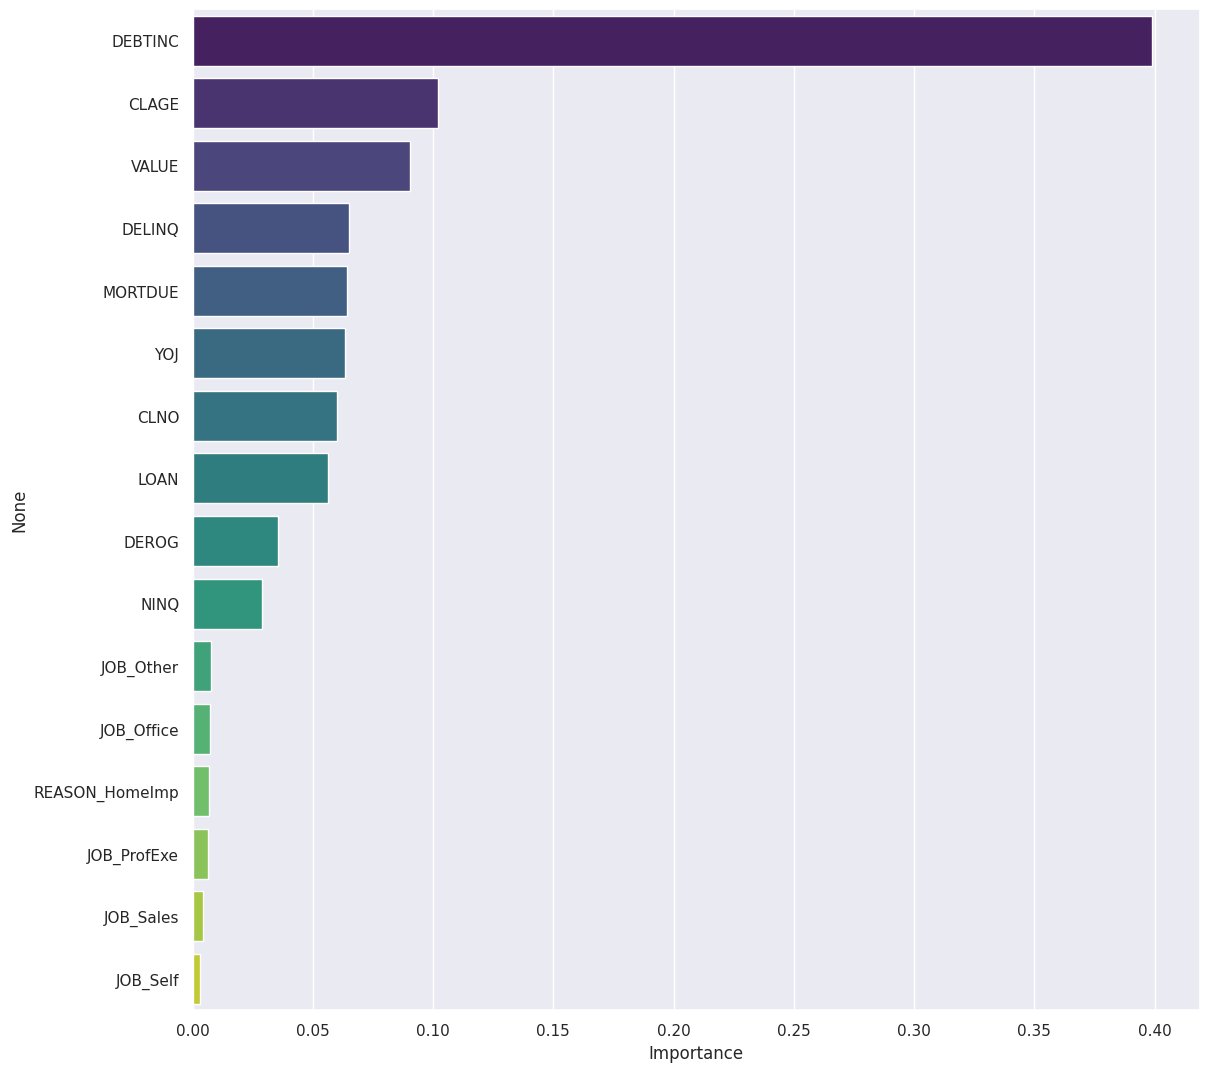

In [73]:
importances = rf_estimator_tuned.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(x=importance_df.Importance, y=importance_df.index, palette='viridis')

**Observations**

* The feature importance of the tuned Random Forest is similar to that of the base model, with **DEBTINC** remaining the most influential feature.
* **CLAGE, VALUE, DELINQ, MORTDUE, YOJ, CLNO, and LOAN** are the next most important features, while the remaining variables have relatively low importance.


# **COMPARING MODEL PERFORMANCES**

In [87]:
def get_recall_score(model, flag=True , X_train=x_train,X_test=x_test):

  a=[]
  pred_train = model.predict(X_train)
  pred_test = model.predict(X_test)
  train_recall = metrics.recall_score(y_train,pred_train)
  test_recall = metrics.recall_score(y_test,pred_test)
  a.append(train_recall)
  a.append(test_recall)
  if flag:
     print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
     print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
  return a

In [86]:
def get_precision_score(model, flag=True , X_train=x_train,X_test=x_test):

  b=[]
  pred_train = model.predict(X_train)
  pred_test = model.predict(X_test)
  train_precision = metrics.precision_score(y_train, pred_train)
  test_precision = metrics.precision_score(y_test, pred_test)
  b.append(train_precision)
  b.append(test_precision)
  if flag == True:
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))
  return b

In [88]:
def get_accuracy_score(model, flag=True , X_train=x_train,X_test=x_test):

  c=[]
  pred_train = model.predict(X_train)
  pred_test = model.predict(X_test)
  train_acc = model.score(X_train,y_train)
  test_acc = model.score(X_test,y_test)
  c.append(train_acc)
  c.append(test_acc)
  if flag == True:
        print("Accuracy on training set : ",metrics.accuracy_score(y_train,pred_train))
        print("Accuracy on test set : ",metrics.accuracy_score(y_test,pred_test))
  return c

In [91]:
# Re-split data to ensure correct train/test sets for each model type
# Data for Logistic Regression (scaled and without NaNs)
x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(X_scaled, Y, test_size = 0.3, random_state = 1, stratify = Y)

x_train_tree, x_test_tree, y_train_tree, y_test_tree = train_test_split(X, Y, test_size = 0.3, random_state = 1, stratify = Y)

models = [rf_estimator_tuned, rf_estimator, dtree_estimator, dt,lg]

acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

for model in models:
    # Determine which data split to use based on the model type
    if model == lg: # Logistic Regression needs scaled data
        current_x_train = x_train_lr
        current_x_test = x_test_lr
        current_y_train = y_train_lr
        current_y_test = y_test_lr
    else: # Tree-based models use unscaled data
        current_x_train = x_train_tree
        current_x_test = x_test_tree
        current_y_train = y_train_tree
        current_y_test = y_test_tree


    l = get_precision_score(model, False, X_train=current_x_train, X_test=current_x_test)
    precision_train.append(l[0])
    precision_test.append(l[1])

    j = get_accuracy_score(model, False, X_train=current_x_train, X_test=current_x_test)
    acc_train.append(j[0])
    acc_test.append(j[1])

    k = get_recall_score(model, False, X_train=current_x_train, X_test=current_x_test)
    recall_train.append(k[0])
    recall_test.append(k[1])

In [92]:
comparision_frame = pd.DataFrame({'Model':['Tuned Random Forest', 'Random Forest', 'Tuned Decision Tree', 'Decision Tree','Logistic Regression'],
                                          'Train_Accuracy': acc_train,
                                          'Test_Accuracy': acc_test,
                                          'Train_Recall': recall_train,
                                          'Test_Recall': recall_test,
                                          'Train_Precision': precision_train,
                                          'Test_Precision': precision_test})

comparision_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Tuned Random Forest,1.000000,0.912192,1.000000,0.708683,1.000000,0.826797
1,Random Forest,1.000000,0.906600,1.000000,0.647059,1.000000,0.849265
2,Tuned Decision Tree,0.858341,0.851790,0.804087,0.759104,0.609845,0.602222
3,Decision Tree,0.999041,0.879195,0.995192,0.627451,1.000000,0.729642
4,Logistic Regression,0.842522,0.832215,0.338942,0.280112,0.724936,0.699301


**Model Comparison**

* The **Tuned Random Forest** achieves the best overall performance with the highest test accuracy (**91.2%**) and a good balance between precision (**82.7%**) and recall (**70.9%**).
* The **Tuned Decision Tree** achieves the highest test recall (**75.9%**) but at the cost of much lower precision (**60.2%**).
* The **Random Forest** performs well but has lower recall than the tuned version.
* **Logistic Regression** gives the lowest recall (**28.0%**) and is the least effective at identifying loan defaulters.
* Overall, the **Tuned Random Forest** is selected as the final model due to its superior balance between accuracy, precision, and recall.
